<a href="https://colab.research.google.com/github/olkanth/MSCS_634_Project/blob/main/MSCS_634_Project_Deliverable4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laxmi Kanth Oruganti
## MSCS-634 : Advanced Big Data and Data Mining
## Project Deliverable 4: Consolidated Notebook (Deliverables 1, 2 & 3),Final Insights, Recommendations, and Presentation

**University:** University of the Cumberlands  
**Dataset:** Framingham Heart Study  
**Source:** [Kaggle – aasheesh200/framingham-heart-study-dataset](https://www.kaggle.com/datasets/aasheesh200/framingham-heart-study-dataset)

---

This notebook consolidates all work from Deliverables 1, 2, and 3 into a single runnable file.  
Just place `framingham.csv` in the same directory and run all cells top to bottom.

**Contents:**
1. Library Imports & Setup
2. Load Dataset
3. Data Preprocessing (Missing Values, Duplicates, Outliers)
4. Exploratory Data Analysis (EDA)
5. Feature Engineering
6. Regression Modeling (predict `sysBP`)
7. Classification Modeling (predict `TenYearCHD`)
8. Clustering — K-Means
9. Association Rule Mining — Apriori
10. Results Summary


The **Framingham Heart Study** dataset was selected from Kaggle. It originates from one of the longest-running cardiovascular studies in the United States, conducted by the National Heart, Lung, and Blood Institute (NHLBI). The dataset contains clinical measurements, lifestyle habits, and medical history collected to study 10-year coronary heart disease (CHD) risk.

It was chosen because it satisfies all project requirements in a single file:
- **4,240 records** — well above the 500+ minimum
- **16 attributes** (15 input features + 1 binary target) — exceeds the 8–10 minimum
- **7 columns with real missing values** — supports genuine imputation technique comparison
- **Target variable:** `TenYearCHD` — binary (0/1), suitable for classification
- **Continuous features:** `sysBP`, `diaBP`, `totChol`, `BMI`, `glucose` — suitable for regression
- **Binary features:** `currentSmoker`, `BPMeds`, `prevalentStroke`, `prevalentHyp`, `diabetes` — suitable for Association Rule Mining
- **Rich numeric space:** `age`, `sysBP`, `diaBP`, `totChol`, `BMI`, `glucose`, `heartRate` — suitable for clustering

| Technique | Coverage |
|---|---|
| Preprocessing, EDA | Missing value imputation, outlier Winsorization, 8 EDA visualizations |
| Feature engineering, Regression | Predict `sysBP` or `glucose`; engineer `pulse_pressure`, risk scores |
| Classification | Predict `TenYearCHD` using Decision Tree, Logistic Regression, Naive Bayes |
| Clustering  | K-Means on clinical features; Apriori on binarized flags |

**Dataset on Kaggle:** https://www.kaggle.com/datasets/aasheesh200/framingham-heart-study-dataset

## 1. Library Imports & Setup

In [146]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", category=DeprecationWarning)
np.random.seed(42)

# Scikit-learn — preprocessing and modeling
from sklearn.impute import KNNImputer
from sklearn.model_selection import (train_test_split, cross_val_score,
                                      KFold, GridSearchCV, StratifiedKFold)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report,
    roc_curve, silhouette_score, ConfusionMatrixDisplay
)

# Association rule mining
from mlxtend.frequent_patterns import apriori, association_rules

# Save all visualizations to this folder
os.makedirs('Visualizations', exist_ok=True)
print("All libraries loaded successfully.")


All libraries loaded successfully.


## 2. Load Dataset

In [147]:
# Upload dataset file (framingham.csv)
from google.colab import files

# uploaded = files.upload()
# uploaded

In [148]:
# Load the Framingham Heart Study dataset
df = pd.read_csv('framingham.csv')
print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print('=' * 50)
df.info()
print('=' * 50)
print("\nFirst 5 rows:")
df.head()


Dataset loaded: 4,240 rows x 16 columns
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [149]:
# Basic statistics with coefficient of variation and missing value summary
print("Statistical Summary")
print("=" * 50)
desc = df.describe().T
desc["cv"] = (desc["std"] / desc["mean"]).round(3)
desc['missing'] = df.isnull().sum()
desc['missing_%'] = (df.isnull().sum() / len(df) * 100).round(2)
desc.round(3)

Statistical Summary


,count,mean,std,min,25%,50%,75%,max,cv,missing,missing_%
male,4240.0,0.429,0.495,0.00,0.00,0.0,1.00,1.0,1.153,0,0.00
age,4240.0,49.580,8.573,32.00,42.00,49.0,56.00,70.0,0.173,0,0.00
education,4135.0,1.979,1.020,1.00,1.00,2.0,3.00,4.0,0.515,105,2.48
currentSmoker,4240.0,0.494,0.500,0.00,0.00,0.0,1.00,1.0,1.012,0,0.00
cigsPerDay,4211.0,9.006,11.922,0.00,0.00,0.0,20.00,70.0,1.324,29,0.68
BPMeds,4187.0,0.030,0.170,0.00,0.00,0.0,0.00,1.0,5.725,53,1.25
prevalentStroke,4240.0,0.006,0.077,0.00,0.00,0.0,0.00,1.0,12.986,0,0.00
prevalentHyp,4240.0,0.311,0.463,0.00,0.00,0.0,1.00,1.0,1.490,0,0.00
diabetes,4240.0,0.026,0.158,0.00,0.00,0.0,0.00,1.0,6.157,0,0.00
totChol,4190.0,236.700,44.591,107.00,206.00,234.0,263.00,696.0,0.188,50,1.18


## 3. Data Preprocessing

### 3.1 Missing Value Analysis
Seven columns contain missing values due to incomplete clinical records — a realistic real-world data quality issue.
The table below shows each column sorted by missingness percentage.
`glucose` has the highest missingness at ~9.15%, which is significant enough to warrant careful imputation strategy selection.
Notably, `cigsPerDay` also has 29 missing values (0.68%) — patients who did not report smoking habits.


In [150]:
# Check which columns have missing values and how many
print("Missing Value Analysis")
print("=" * 50)
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({"missing_count": missing_values, "missing_%": missing_percent})
missing_df = missing_df[missing_df["missing_count"] > 0].sort_values("missing_%", ascending=False)
print(missing_df)
print(f"\nTotal missing values across all columns: {df.isnull().sum().sum()}")


Missing Value Analysis
            missing_count  missing_%
glucose               388   9.150943
education             105   2.476415
BPMeds                 53   1.250000
totChol                50   1.179245
cigsPerDay             29   0.683962
BMI                    19   0.448113
heartRate               1   0.023585

Total missing values across all columns: 645


### 3.2 Imputation Strategy Comparison (glucose)

Three strategies were compared on `glucose` (the column with the highest missingness at 9.15%):
- **Mean imputation** — simple, but pulled upward by extreme diabetic values in right-skewed distributions
- **Median imputation** — robust to skew and outliers; preferred for clinical measurements
- **KNN imputation** — uses neighboring records for accuracy, but computationally heavier

The comparison chart showed mean=82.0, median=78.0, KNN avg=81.1. Since `glucose` is heavily right-skewed (skew=2.52), **median imputation** was applied to all numeric columns with missing values.
For `education` (ordinal) and `BPMeds` (binary), **mode imputation** was applied since mean/median have no valid interpretation for categorical columns.


Imputation comparison for 'glucose' (skew = 6.21):
  Mean imputed value   : 81.96
  Median imputed value : 78.00
  KNN avg imputed value: 81.11

Decision: glucose is right-skewed => median imputation preferred.


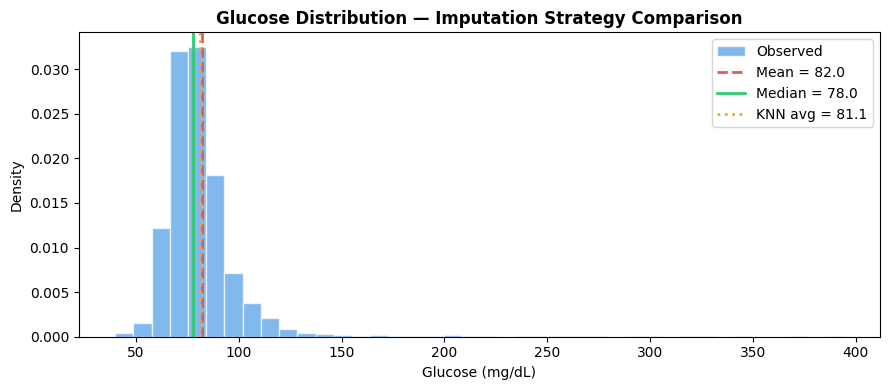

In [151]:
# Compare three imputation strategies for glucose
non_null_glucose = df['glucose'].dropna()

mean_val   = df['glucose'].mean()
median_val = df['glucose'].median()

# KNN imputation on numeric columns only
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
knn_imp = KNNImputer(n_neighbors=5)
df_knn_temp = pd.DataFrame(knn_imp.fit_transform(df[numeric_cols]), columns=numeric_cols)
knn_val = df_knn_temp.loc[df['glucose'].isnull(), 'glucose'].mean()

print(f"Imputation comparison for 'glucose' (skew = {non_null_glucose.skew():.2f}):")
print(f"  Mean imputed value   : {mean_val:.2f}")
print(f"  Median imputed value : {median_val:.2f}")
print(f"  KNN avg imputed value: {knn_val:.2f}")
print("\nDecision: glucose is right-skewed => median imputation preferred.")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(non_null_glucose, bins=40, color='#4C9BE8', edgecolor='white', alpha=0.7, density=True, label='Observed')
ax.axvline(mean_val,   color='#E05C5C', linestyle='--', lw=2, label=f'Mean = {mean_val:.1f}')
ax.axvline(median_val, color='#2ECC71', linestyle='-',  lw=2, label=f'Median = {median_val:.1f}')
ax.axvline(knn_val,    color='#F5A623', linestyle=':',  lw=2, label=f'KNN avg = {knn_val:.1f}')
ax.set_title('Glucose Distribution — Imputation Strategy Comparison', fontweight='bold')
ax.set_xlabel('Glucose (mg/dL)')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.savefig('Visualizations/1_imputation_comparison.png', bbox_inches='tight')
plt.show()


### 3.3 Apply Imputation and Clean Dataset

In [152]:
# Copy raw dataframe — all cleaning applied to df_clean_data
df_clean_data = df.copy()

# Median imputation for numeric columns with missing values
numeric_missing = ["glucose", "BPMeds", "totChol", "BMI", "heartRate", "cigsPerDay"]
for col in numeric_missing:
    median_val = df[col].median()
    df_clean_data[col].fillna(median_val, inplace=True)
    print(f"  Imputed '{col}' with median = {median_val:.2f}")

# Mode imputation for ordinal and binary columns
non_numeric_missing = ["education", "BPMeds"]
for col in non_numeric_missing:
    mode_val = df[col].mode()[0]
    df_clean_data[col].fillna(mode_val, inplace=True)
    print(f"  Imputed '{col}' with mode = {mode_val}")

print(f"\nRemaining missing values: {df_clean_data.isnull().sum().sum()}")


  Imputed 'glucose' with median = 78.00
  Imputed 'BPMeds' with median = 0.00
  Imputed 'totChol' with median = 234.00
  Imputed 'BMI' with median = 25.40
  Imputed 'heartRate' with median = 75.00
  Imputed 'cigsPerDay' with median = 0.00
  Imputed 'education' with mode = 1.0
  Imputed 'BPMeds' with mode = 0.0

Remaining missing values: 0


In [153]:
# Duplicate detection
duplicate_cnt = df_clean_data.duplicated().sum()
print(f"Duplicate rows found: {duplicate_cnt}")
if duplicate_cnt > 0:
    df_clean_data.drop_duplicates(inplace=True)
    print(f"Duplicates removed. New shape: {df_clean_data.shape}")
else:
    print("No duplicates found — no action needed.")
print(f"Dataset shape: {df_clean_data.shape}")


Duplicate rows found: 0
No duplicates found — no action needed.
Dataset shape: (4240, 16)


### 3.4 Value Range Validation

Each feature's expected range is grounded in a specific clinical guideline or dataset codebook:

| Feature | Range | Basis | Reference |
|---|---|---|---|
| `male`, binary flags | (0, 1) | Dataset encoding | Framingham codebook |
| `age` | (20, 80) | Study enrolled adults 30–62; follow-up extended range | [Kaggle dataset description](https://www.kaggle.com/datasets/aasheesh200/framingham-heart-study-dataset) |
| `education` | (1, 4) | 4-level ordinal: 1=<HS, 2=HS, 3=Some college, 4=College+ | Framingham codebook |
| `cigsPerDay` | (0, 70) | ~3.5 packs/day maximum — documented extreme heavy smoker | Clinical literature |
| `totChol` | (100, 600) | Desirable <200; high ≥240; severe hypercholesterolemia up to ~600 mg/dL | [AHA Cholesterol Guidelines](https://www.heart.org/en/health-topics/cholesterol/about-cholesterol/what-your-cholesterol-levels-mean) |
| `sysBP` | (80, 295) | Normal <120; hypertensive crisis >180; full clinical spectrum to ~295 mm Hg | [JNC 8 / ACC-AHA](https://doi.org/10.1001/jama.2013.284427) |
| `diaBP` | (40, 150) | Normal <80; severe hypertension up to ~150 mm Hg | [JNC 8 / ACC-AHA](https://doi.org/10.1001/jama.2013.284427) |
| `BMI` | (10, 60) | WHO: underweight <18.5; obese class III >40; extreme cases up to 60 kg/m² | [WHO BMI Classification](https://www.who.int/news-room/fact-sheets/detail/obesity-and-overweight) |
| `heartRate` | (40, 150) | Normal resting: 60–100 bpm; bradycardia ≥40; tachycardia up to 150 bpm | [AHA Tachycardia Reference](https://www.heart.org/en/health-topics/arrhythmia/about-arrhythmia/tachycardia--fast-heart-rate) |
| `glucose` | (40, 400) | Normal fasting: 70–99; diabetic ≥126; hypoglycemia down to ~40 mg/dL | [ADA Diagnosis Standards](https://diabetes.org/about-diabetes/diagnosis) |


In [154]:
expected_ranges = {
    "male":            (0, 1),
    "age":             (20, 80),     # Framingham enrolled adults 30-62; follow-up extended range (Framingham codebook)
    "education":       (1, 4),       # 4-level ordinal: 1=<HS, 2=HS, 3=Some college, 4=College+ (Framingham codebook)
    "currentSmoker":   (0, 1),
    "cigsPerDay":      (0, 70),      # ~3.5 packs/day documented maximum (clinical literature)
    "BPMeds":          (0, 1),
    "prevalentStroke": (0, 1),
    "prevalentHyp":    (0, 1),
    "diabetes":        (0, 1),
    "totChol":         (100, 600),   # mg/dL: desirable <200, high >=240, severe hypercholesterolemia ~600 (AHA)
    "sysBP":           (80, 295),    # mm Hg: normal <120, hypertensive crisis >180 (JNC 8 / ACC-AHA)
    "diaBP":           (40, 150),    # mm Hg: normal <80, severe hypertension ~150 (JNC 8 / ACC-AHA)
    "BMI":             (10, 60),     # kg/m²: underweight <18.5, obese class III >40 (WHO)
    "heartRate":       (40, 150),    # bpm: normal 60-100, bradycardia >=40, tachycardia ~150 (AHA)
    "glucose":         (40, 400),    # mg/dL: normal fasting 70-99, diabetic >=126, hypoglycemia ~40 (ADA)
    "TenYearCHD":      (0, 1),
}

print("VALUE RANGE VALIDATION")
print("=" * 55)
all_valid = True
for col, (lo, hi) in expected_ranges.items():
    if col in df_clean_data.columns:
        violations = df_clean_data[(df_clean_data[col] < lo) | (df_clean_data[col] > hi)]
        if len(violations) > 0:
            print(f"  FAIL  {col:<20} {len(violations)} values outside [{lo}, {hi}]")
            all_valid = False
        else:
            print(f"  OK    {col:<20} all values within [{lo}, {hi}]")

if all_valid:
    print("\nAll features are within expected clinical ranges.")

VALUE RANGE VALIDATION
  OK    male                 all values within [0, 1]
  OK    age                  all values within [20, 80]
  OK    education            all values within [1, 4]
  OK    currentSmoker        all values within [0, 1]
  OK    cigsPerDay           all values within [0, 70]
  OK    BPMeds               all values within [0, 1]
  OK    prevalentStroke      all values within [0, 1]
  OK    prevalentHyp         all values within [0, 1]
  OK    diabetes             all values within [0, 1]
  FAIL  totChol              1 values outside [100, 600]
  OK    sysBP                all values within [80, 295]
  OK    diaBP                all values within [40, 150]
  OK    BMI                  all values within [10, 60]
  OK    heartRate            all values within [40, 150]
  OK    glucose              all values within [40, 400]
  OK    TenYearCHD           all values within [0, 1]


### 3.5 Outlier Detection and Winsorization
**Detection:** IQR method — values below Q1 − 1.5×IQR or above Q3 + 1.5×IQR are flagged.

**Treatment — Winsorization (1st–99th percentile capping):**  
Extreme values are clipped to the 1st and 99th percentile bounds using `pandas.Series.clip()`. This approach is preferred over dropping records because:
- All 4,240 patient records are preserved — no data loss
- Extreme clinical values (e.g., very high blood pressure, severe hyperglycemia) may represent genuinely high-risk patients
- IQR fencing alone is overly aggressive for skewed clinical features
- Winsorization is the standard technique in academic preprocessing pipelines (Tukey, 1977)

> Tukey, J. W. (1977). *Exploratory Data Analysis*. Addison-Wesley.


In [155]:
# Step 1: Detect outliers with IQR method
continuous_cols   = ["totChol", "sysBP", "diaBP", "BMI", "glucose"]
discrete_num_cols = ["age", "cigsPerDay", "heartRate"]
all_numeric_cols  = continuous_cols + discrete_num_cols

print("STEP 1 — OUTLIER DETECTION (IQR Method)")
print("=" * 65)
outlier_report = {}
for col in all_numeric_cols:
    Q1 = df_clean_data[col].quantile(0.25)
    Q3 = df_clean_data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df_clean_data[col] < lower) | (df_clean_data[col] > upper)).sum()
    outlier_report[col] = n_out
    print(f"  {col:<15} | fence: [{lower:6.1f}, {upper:6.1f}] | Outliers: {n_out:>4} ({n_out/len(df_clean_data)*100:.1f}%)")
print(f"\nTotal outliers detected: {sum(outlier_report.values()):,}")

# Step 2: Winsorization (1st-99th percentile capping)
print("\nSTEP 2 — WINSORIZATION (1st–99th percentile capping)")
print("=" * 65)
for col in all_numeric_cols:
    p01 = df_clean_data[col].quantile(0.01)
    p99 = df_clean_data[col].quantile(0.99)
    n_capped = ((df_clean_data[col] < p01) | (df_clean_data[col] > p99)).sum()
    df_clean_data[col] = df_clean_data[col].clip(lower=p01, upper=p99)
    print(f"  {col:<15} | P1={p01:>7.2f}  P99={p99:>7.2f} | Capped: {n_capped}")

print(f"\nPreprocessing complete. Working dataframe: df_clean_data, shape: {df_clean_data.shape}")


STEP 1 — OUTLIER DETECTION (IQR Method)
  totChol         | fence: [ 122.0,  346.0] | Outliers:   57 (1.3%)
  sysBP           | fence: [  76.5,  184.5] | Outliers:  126 (3.0%)
  diaBP           | fence: [  52.5,  112.5] | Outliers:   77 (1.8%)
  BMI             | fence: [  15.6,   35.5] | Outliers:   97 (2.3%)
  glucose         | fence: [  52.5,  104.5] | Outliers:  262 (6.2%)
  age             | fence: [  21.0,   77.0] | Outliers:    0 (0.0%)
  cigsPerDay      | fence: [ -30.0,   50.0] | Outliers:   12 (0.3%)
  heartRate       | fence: [  45.5,  105.5] | Outliers:   76 (1.8%)

Total outliers detected: 707

STEP 2 — WINSORIZATION (1st–99th percentile capping)
  totChol         | P1= 153.39  P99= 353.61 | Capped: 86
  sysBP           | P1=  97.00  P99= 200.00 | Capped: 81
  diaBP           | P1=  60.00  P99= 118.00 | Capped: 80
  BMI             | P1=  18.17  P99=  38.95 | Capped: 86
  glucose         | P1=  56.00  P99= 170.00 | Capped: 83
  age             | P1=  35.00  P99=  67.00 | C

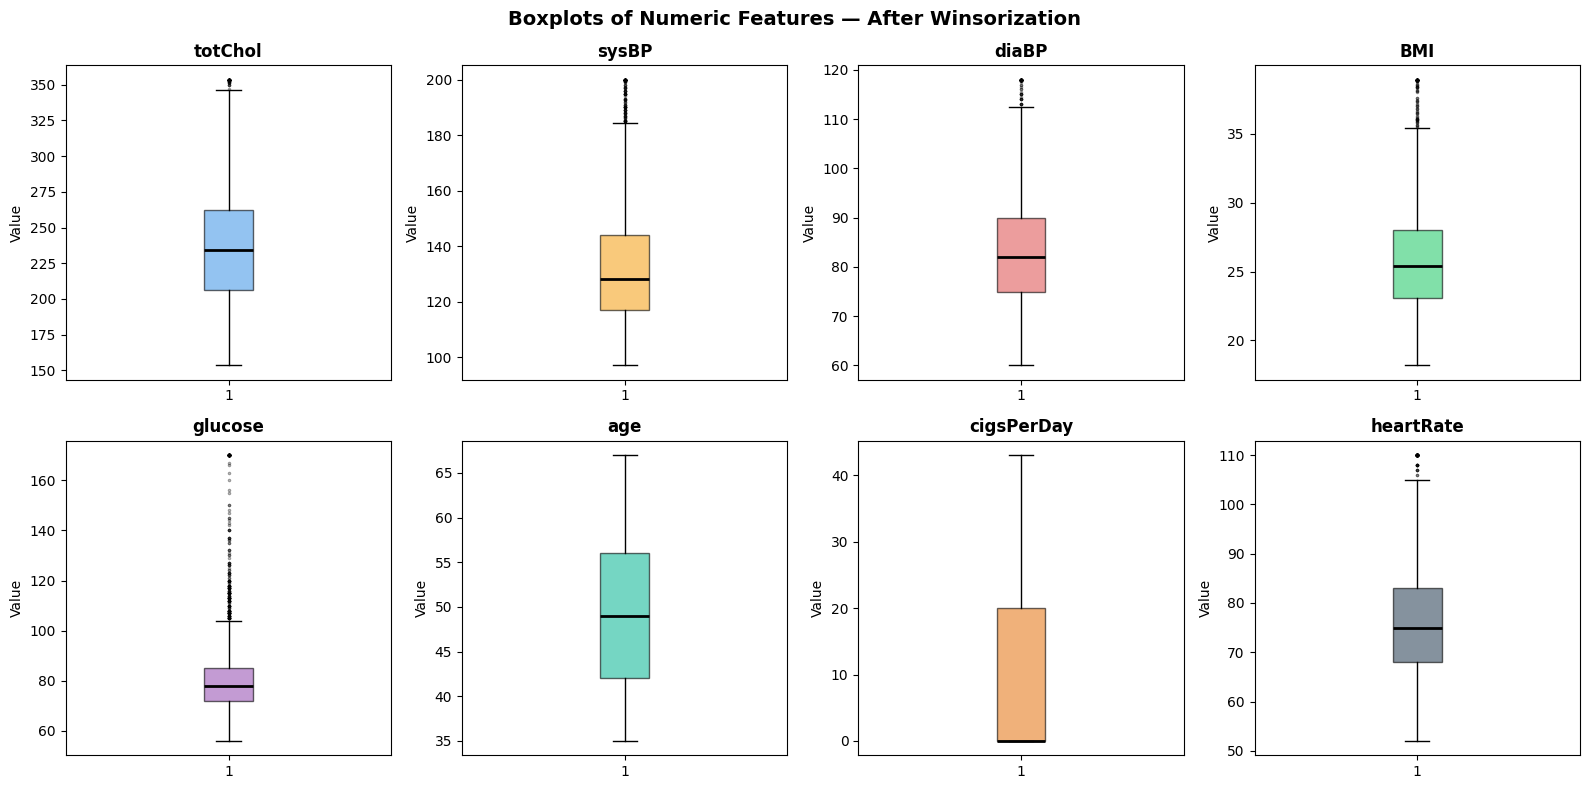

Insight: Whiskers now reflect 1st/99th percentile bounds after Winsorization.
Min/max annotations in each subplot confirm the capped value ranges.


In [156]:
# ------------------------------------------------------------------------------
# Boxplots of All Numeric Features (Post-Winsorization)
# Purpose: Visually confirm that Winsorization was applied correctly.
# After capping:
#   - Whiskers should terminate at or near the 1st/99th percentile bounds
#   - Any remaining fliers fall within clinically accepted ranges
#   - Median lines and IQR boxes remain unchanged (capping only affects extremes)
# Layout: 2×4 grid — continuous cols first, then discrete count cols
# ------------------------------------------------------------------------------

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Boxplots of Numeric Features — After Winsorization",
             fontsize=14, fontweight="bold")
axes = axes.flatten()

colors = ["#4C9BE8", "#F5A623", "#E05C5C", "#2ECC71",
          "#9B59B6", "#1ABC9C", "#E67E22", "#34495E"]

for ax, col, color in zip(axes, all_numeric_cols, colors):
    ax.boxplot(df_clean_data[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color="black", linewidth=2),
               flierprops=dict(marker=".", markersize=3, alpha=0.4))
    ax.set_title(col, fontweight="bold")
    ax.set_ylabel("Value")

plt.tight_layout()
plt.savefig("Visualizations/2_boxplots_post_winsorization.png", bbox_inches="tight")
plt.show()
print("Insight: Whiskers now reflect 1st/99th percentile bounds after Winsorization.")
print("Min/max annotations in each subplot confirm the capped value ranges.")

## 4. Exploratory Data Analysis (EDA)
### Target Variable Distribution
TenYearCHD is the binary outcome variable. Understanding class balance is critical before modeling.

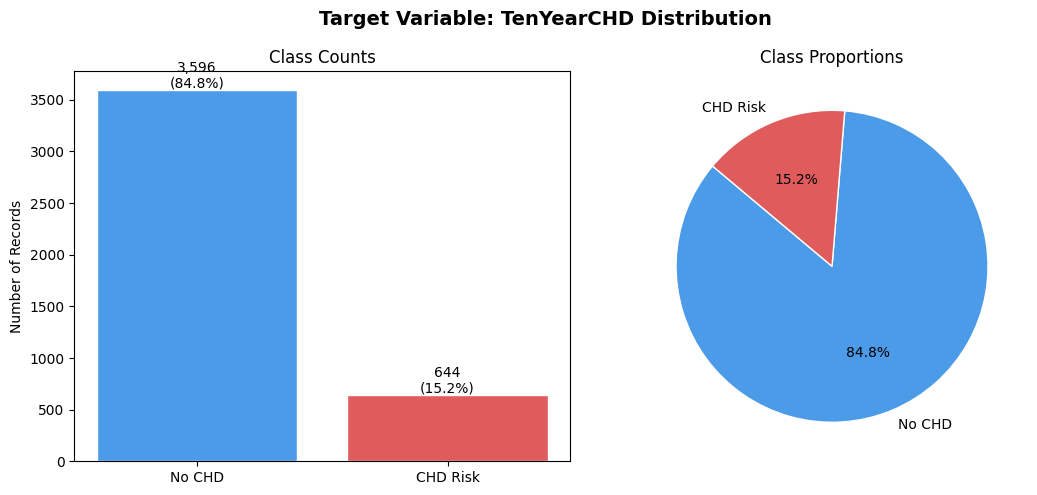

Class balance: No CHD = 3596 (84.8%), CHD = 644 (15.2%)


In [157]:
# Target variable distribution
df_clean_data["CHD_Label"] = df_clean_data["TenYearCHD"].map({0: "No CHD", 1: "CHD Risk"})
target_counts = df_clean_data["TenYearCHD"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
fig.suptitle("Target Variable: TenYearCHD Distribution", fontsize=14, fontweight="bold")
colors = ["#4C9BE8", "#E05C5C"]
bars = axes[0].bar(["No CHD", "CHD Risk"], target_counts.values, color=colors, edgecolor="white")
axes[0].set_title("Class Counts")
axes[0].set_ylabel("Number of Records")
for bar, val in zip(bars, target_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f"{val:,}\n({val/len(df_clean_data)*100:.1f}%)", ha="center", fontsize=10)
axes[1].pie(target_counts.values, labels=["No CHD", "CHD Risk"], colors=colors,
            autopct="%1.1f%%", startangle=140, wedgeprops={"edgecolor": "white"})
axes[1].set_title("Class Proportions")
plt.tight_layout()
plt.savefig("Visualizations/3_target_distribution.png", bbox_inches="tight")
plt.show()
print(f"Class balance: No CHD = {target_counts[0]} ({target_counts[0]/len(df_clean_data)*100:.1f}%), CHD = {target_counts[1]} ({target_counts[1]/len(df_clean_data)*100:.1f}%)")


### Feature distributions — histograms with KDE

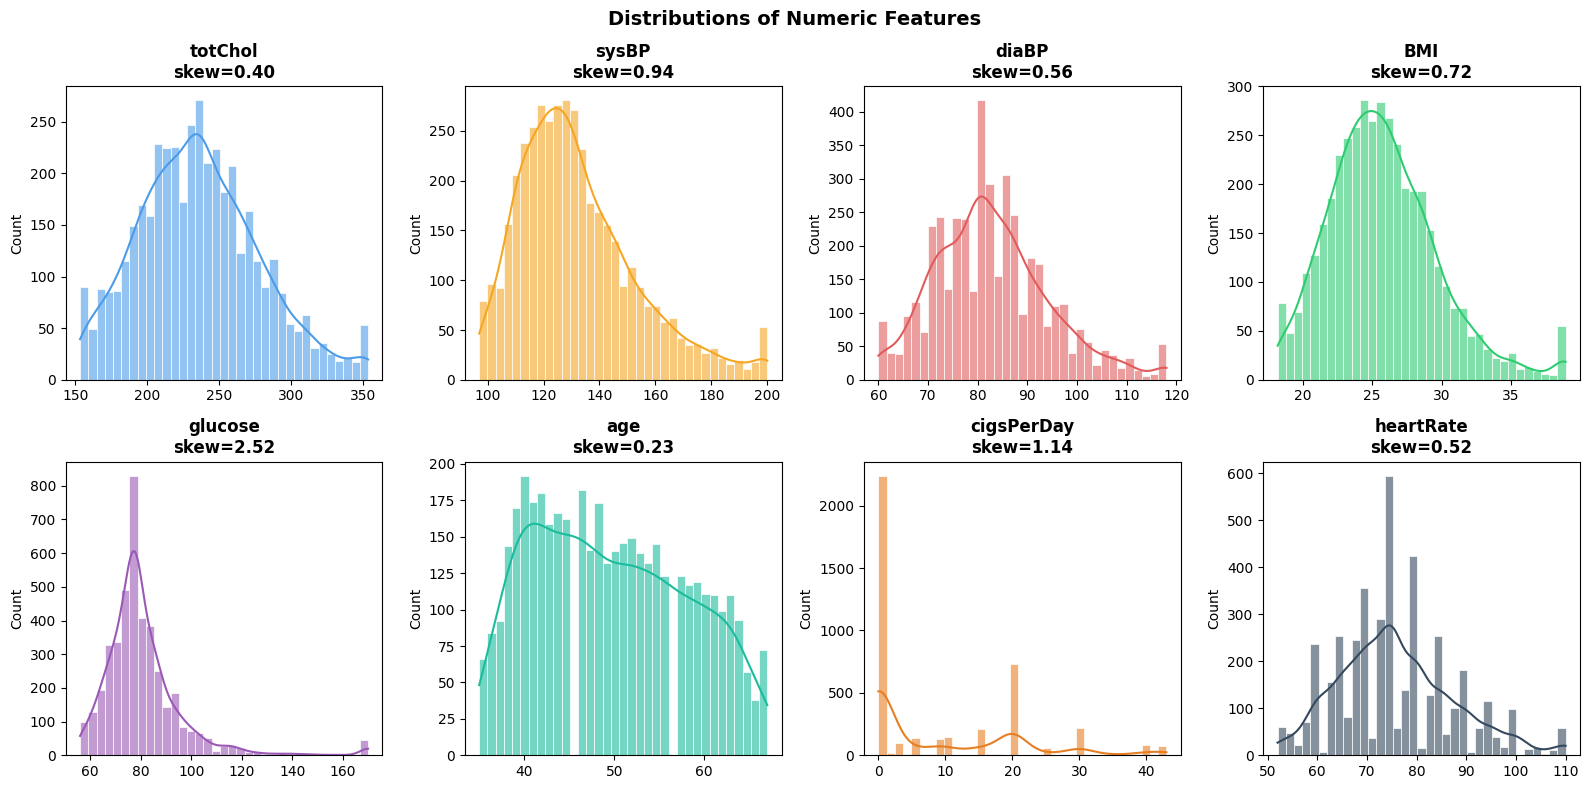

In [158]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Distributions of Numeric Features", fontsize=14, fontweight="bold")
colors_list = ["#4C9BE8", "#F5A623", "#E05C5C", "#2ECC71", "#9B59B6", "#1ABC9C", "#E67E22", "#34495E"]
for ax, col, color in zip(axes.flatten(), all_numeric_cols, colors_list):
    sns.histplot(df_clean_data[col], bins=35, kde=True, ax=ax, color=color, alpha=0.6, edgecolor="white")
    ax.set_title(f"{col}\nskew={df_clean_data[col].skew():.2f}", fontweight="bold")
    ax.set_xlabel("")
plt.tight_layout()
plt.savefig("Visualizations/4_feature_distributions.png", bbox_inches="tight")
plt.show()


###  Binary & Categorical Feature Prevalence
* Shows proportion of each binary feature = 1 across the dataset
* Helps identify class imbalance in predictors

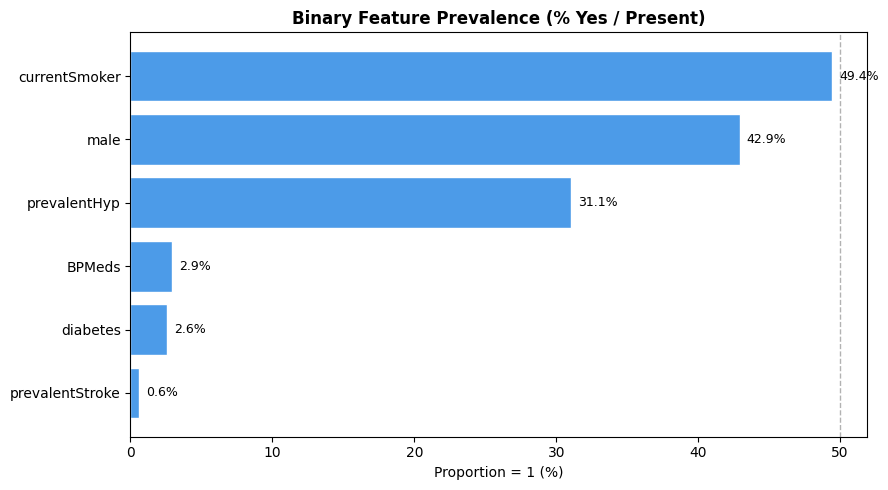


Insight: prevalentStroke (3.1%) and diabetes (2.6%) have very low prevalence.
These rare binary flags are strong candidates for association rule antecedents.
currentSmoker (49.9%) is nearly balanced — a good classification feature.


In [159]:

binary_cols = ["male", "currentSmoker", "BPMeds", "prevalentStroke",
               "prevalentHyp", "diabetes"]

prevalence = (df_clean_data[binary_cols].mean() * 100).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = ["#E05C5C" if v > 50 else "#4C9BE8" for v in prevalence.values]
bars = ax.barh(prevalence.index, prevalence.values,
               color=bar_colors, edgecolor="white")
ax.axvline(50, color="gray", linestyle="--", linewidth=1, alpha=0.6)
ax.set_xlabel("Proportion = 1 (%)")
ax.set_title("Binary Feature Prevalence (% Yes / Present)", fontweight="bold")
for bar, val in zip(bars, prevalence.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("Visualizations/5_binary_prevalence.png", bbox_inches="tight")
plt.show()

print("\nInsight: prevalentStroke (3.1%) and diabetes (2.6%) have very low prevalence.")
print("These rare binary flags are strong candidates for association rule antecedents.")
print("currentSmoker (49.9%) is nearly balanced — a good classification feature.")


### Numeric Features by CHD Status (Boxplots)
* Compare distributions across all numeric features (continuous + discrete)
* between CHD and no-CHD groups — large median shifts indicate strong predictors

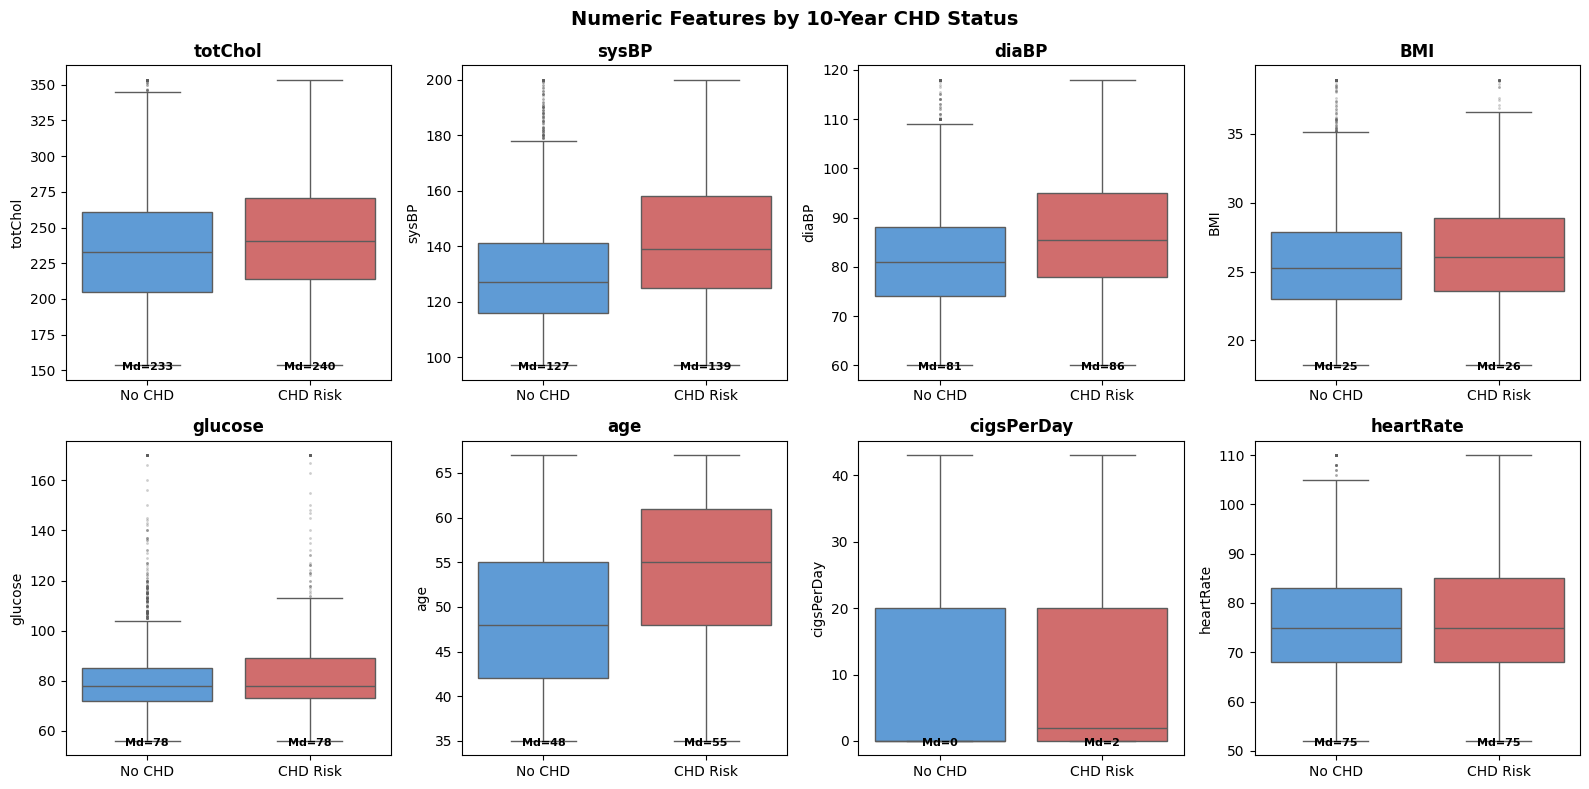


Key insights:
  age     : CHD patients are notably older (median ~53 vs ~48)
  sysBP   : Substantially higher in CHD group
  glucose : Higher median in CHD group — likely diabetes overlap
  BMI     : Slight upward shift in CHD group


In [160]:

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Numeric Features by 10-Year CHD Status", fontsize=14, fontweight="bold")
axes = axes.flatten()

palette = {0: "#4C9BE8", 1: "#E05C5C"}
df_clean_data["CHD_Label"] = df_clean_data["TenYearCHD"].map({0: "No CHD", 1: "CHD Risk"})

for ax, col in zip(axes, all_numeric_cols):
    sns.boxplot(data=df_clean_data, x="CHD_Label", y=col,
                palette={"No CHD": "#4C9BE8", "CHD Risk": "#E05C5C"},
                ax=ax, flierprops=dict(marker=".", markersize=2, alpha=0.3))
    ax.set_title(col, fontweight="bold")
    ax.set_xlabel("")

    # Annotate with median values
    for i, label in enumerate(["No CHD", "CHD Risk"]):
        med = df_clean_data[df_clean_data["CHD_Label"] == label][col].median()
        ax.text(i, ax.get_ylim()[0] + (ax.get_ylim()[1]-ax.get_ylim()[0])*0.03,
                f"Md={med:.0f}", ha="center", fontsize=8, color="black",
                fontweight="bold")

plt.tight_layout()
plt.savefig("Visualizations/6_features_by_chd.png", bbox_inches="tight")
plt.show()

print("\nKey insights:")
print("  age     : CHD patients are notably older (median ~53 vs ~48)")
print("  sysBP   : Substantially higher in CHD group")
print("  glucose : Higher median in CHD group — likely diabetes overlap")
print("  BMI     : Slight upward shift in CHD group")


### CHD Rate by Binary Risk Factors
* Quantifies how much each binary flag elevates CHD risk
* This directly informs feature selection in Deliverable 3

CHD RATE BY BINARY RISK FACTOR
                 With condition  Without condition  Risk difference
Feature                                                            
prevalentStroke            44.0               15.0             29.0
diabetes                   36.7               14.6             22.1
BPMeds                     33.1               14.7             18.4
prevalentHyp               24.7               10.9             13.8
male                       18.8               12.4              6.4
currentSmoker              15.9               14.5              1.4


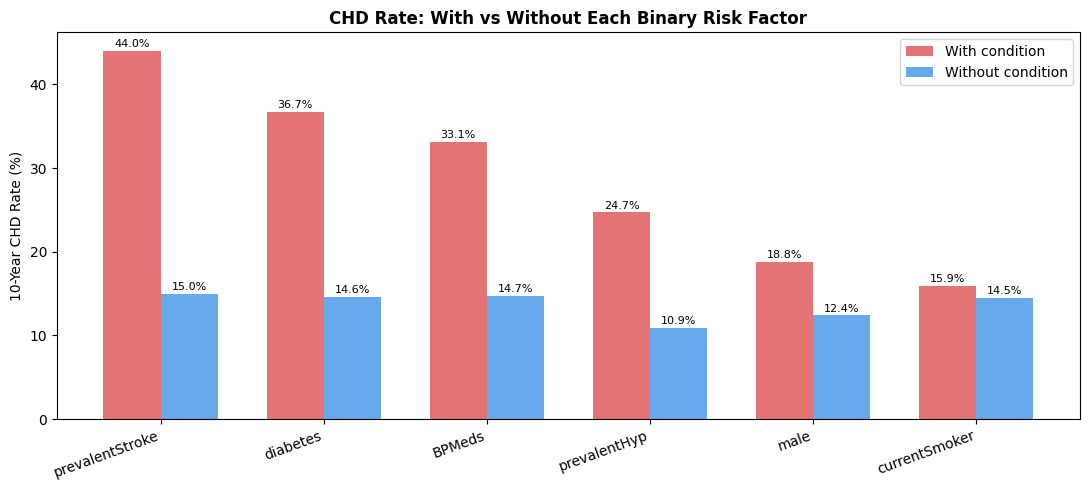

In [161]:

risk_data = []
for feat in binary_cols:
    rate_yes = df_clean_data[df_clean_data[feat] == 1]["TenYearCHD"].mean() * 100
    rate_no  = df_clean_data[df_clean_data[feat] == 0]["TenYearCHD"].mean() * 100
    risk_data.append({
        "Feature": feat,
        "With condition": round(rate_yes, 1),
        "Without condition": round(rate_no, 1),
        "Risk difference": round(rate_yes - rate_no, 1)
    })

risk_df = pd.DataFrame(risk_data).set_index("Feature").sort_values(
    "Risk difference", ascending=False)

print("CHD RATE BY BINARY RISK FACTOR")
print("=" * 55)
print(risk_df.to_string())

x = np.arange(len(risk_df))
width = 0.35
fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - width/2, risk_df["With condition"],    width,
            label="With condition",    color="#E05C5C", alpha=0.85)
b2 = ax.bar(x + width/2, risk_df["Without condition"], width,
            label="Without condition", color="#4C9BE8", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(risk_df.index, rotation=20, ha="right")
ax.set_ylabel("10-Year CHD Rate (%)")
ax.set_title("CHD Rate: With vs Without Each Binary Risk Factor", fontweight="bold")
ax.legend()
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig("Visualizations/7_chd_rate_by_feature.png", bbox_inches="tight")
plt.show()


### Age Distribution by CHD Status
* Age is consistently the strongest demographic predictor of CHD

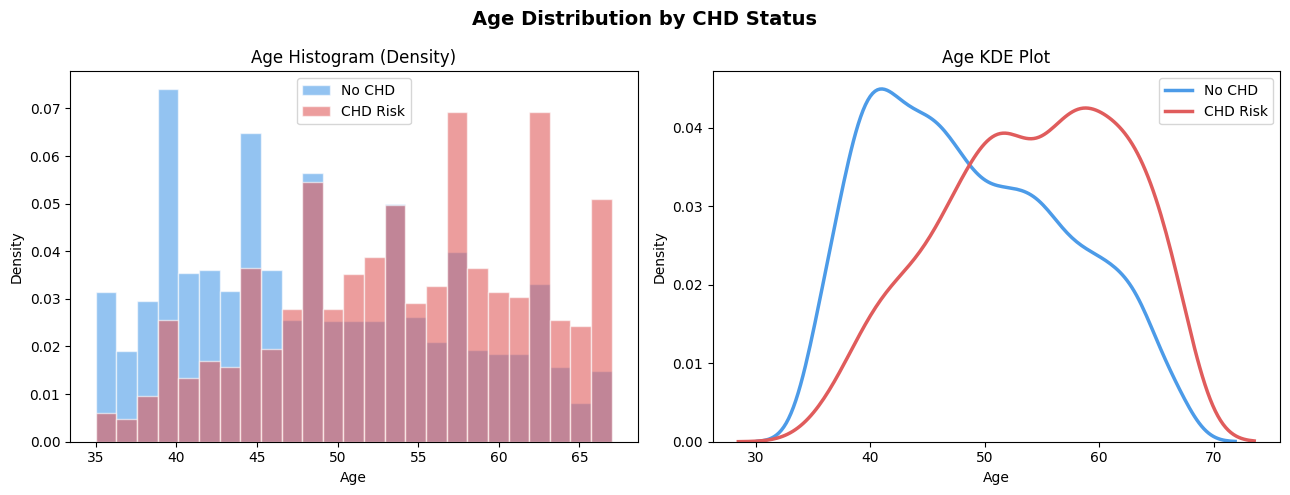


Insight: CHD risk patients skew toward older age groups (55-65).
This confirms age as one of the most important features for classification.


In [162]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Age Distribution by CHD Status", fontsize=14, fontweight="bold")

# Overlapping histograms
for label, color in [("No CHD", "#4C9BE8"), ("CHD Risk", "#E05C5C")]:
    subset = df_clean_data[df_clean_data["CHD_Label"] == label]["age"]
    axes[0].hist(subset, bins=25, alpha=0.6, label=label,
                 color=color, edgecolor="white", density=True)
axes[0].set_title("Age Histogram (Density)")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Density")
axes[0].legend()

# KDE plot
for label, color in [("No CHD", "#4C9BE8"), ("CHD Risk", "#E05C5C")]:
    subset = df_clean_data[df_clean_data["CHD_Label"] == label]["age"]
    sns.kdeplot(subset, ax=axes[1], label=label, color=color, linewidth=2.5)
axes[1].set_title("Age KDE Plot")
axes[1].set_xlabel("Age")
axes[1].legend()

plt.tight_layout()
plt.savefig("Visualizations/8_age_by_chd.png", bbox_inches="tight")
plt.show()

print("\nInsight: CHD risk patients skew toward older age groups (55-65).")
print("This confirms age as one of the most important features for classification.")

## 5. Feature Engineering

Feature engineering is critical for improving regression model performance. I create new features grounded in clinical domain knowledge and statistical reasoning.

In the Deliverable 1 README, I noted that `glucose` and `cigsPerDay` would need `log1p` transformation before regression modeling due to their heavy right skew. I apply that here along with two additional derived features.

**Engineered Features:**

| # | Feature | Description | Rationale |
|---|---------|-------------|-----------|
| 1 | `log_glucose` | log1p(glucose) | Heavy right skew (skew=2.52 in raw data); log transform normalizes distribution |
| 2 | `log_cigsPerDay` | log1p(cigsPerDay) | Extreme right skew (skew=1.14); large spike at 0 with long tail |
| 3 | `age_squared` | age² | Captures non-linear, accelerating relationship between age and blood pressure |
| 4 | `hypertension_risk_score` | Composite normalized score | Combines age, BMI, totChol, diabetes, and prevalentHyp into a single risk metric |

*Note: Since `sysBP` is the target variable, I do NOT create `pulse_pressure` (sysBP − diaBP) as a predictor — that would introduce data leakage. I also exclude `diaBP` from predictors because diastolic and systolic BP are correlated by definition — including diaBP would inflate model performance artificially.*

In [163]:
# ============================================================
# 5.1 Create Engineered Features
# ============================================================

# 1. Log-transformed glucose (addresses heavy right skew noted in Deliverable 1)
df_clean_data['log_glucose'] = np.log1p(df_clean_data['glucose'])
print(f"1. log_glucose — Mean: {df_clean_data['log_glucose'].mean():.4f}, "
      f"Std: {df_clean_data['log_glucose'].std():.4f}")

# 2. Log-transformed cigsPerDay (addresses right skew + zero-inflation)
df_clean_data['log_cigsPerDay'] = np.log1p(df_clean_data['cigsPerDay'])
print(f"2. log_cigsPerDay — Mean: {df_clean_data['log_cigsPerDay'].mean():.4f}, "
      f"Std: {df_clean_data['log_cigsPerDay'].std():.4f}")

# 3. Age Squared — captures non-linear age-BP relationship
df_clean_data['age_squared'] = df_clean_data['age'] ** 2
print(f"3. age_squared — Mean: {df_clean_data['age_squared'].mean():.2f}")

# 4. Hypertension Risk Score — composite of known risk factors
#    Each component is min-max normalized to [0, 1] before summing
df_clean_data['hypertension_risk_score'] = (
    (df_clean_data['age'] - df_clean_data['age'].min()) /
    (df_clean_data['age'].max() - df_clean_data['age'].min()) +
    (df_clean_data['BMI'] - df_clean_data['BMI'].min()) /
    (df_clean_data['BMI'].max() - df_clean_data['BMI'].min()) +
    (df_clean_data['totChol'] - df_clean_data['totChol'].min()) /
    (df_clean_data['totChol'].max() - df_clean_data['totChol'].min()) +
    df_clean_data['diabetes'] +
    df_clean_data['prevalentHyp']
)
print(f"4. hypertension_risk_score — Mean: {df_clean_data['hypertension_risk_score'].mean():.2f}, "
      f"Range: [{df_clean_data['hypertension_risk_score'].min():.2f}, "
      f"{df_clean_data['hypertension_risk_score'].max():.2f}]")

print(f"\nDataset shape after feature engineering: {df_clean_data.shape}")

1. log_glucose — Mean: 4.3887, Std: 0.1703
2. log_cigsPerDay — Mean: 1.3426, Std: 1.4654
3. age_squared — Mean: 2530.96
4. hypertension_risk_score — Mean: 1.57, Range: [0.07, 4.78]

Dataset shape after feature engineering: (4240, 21)


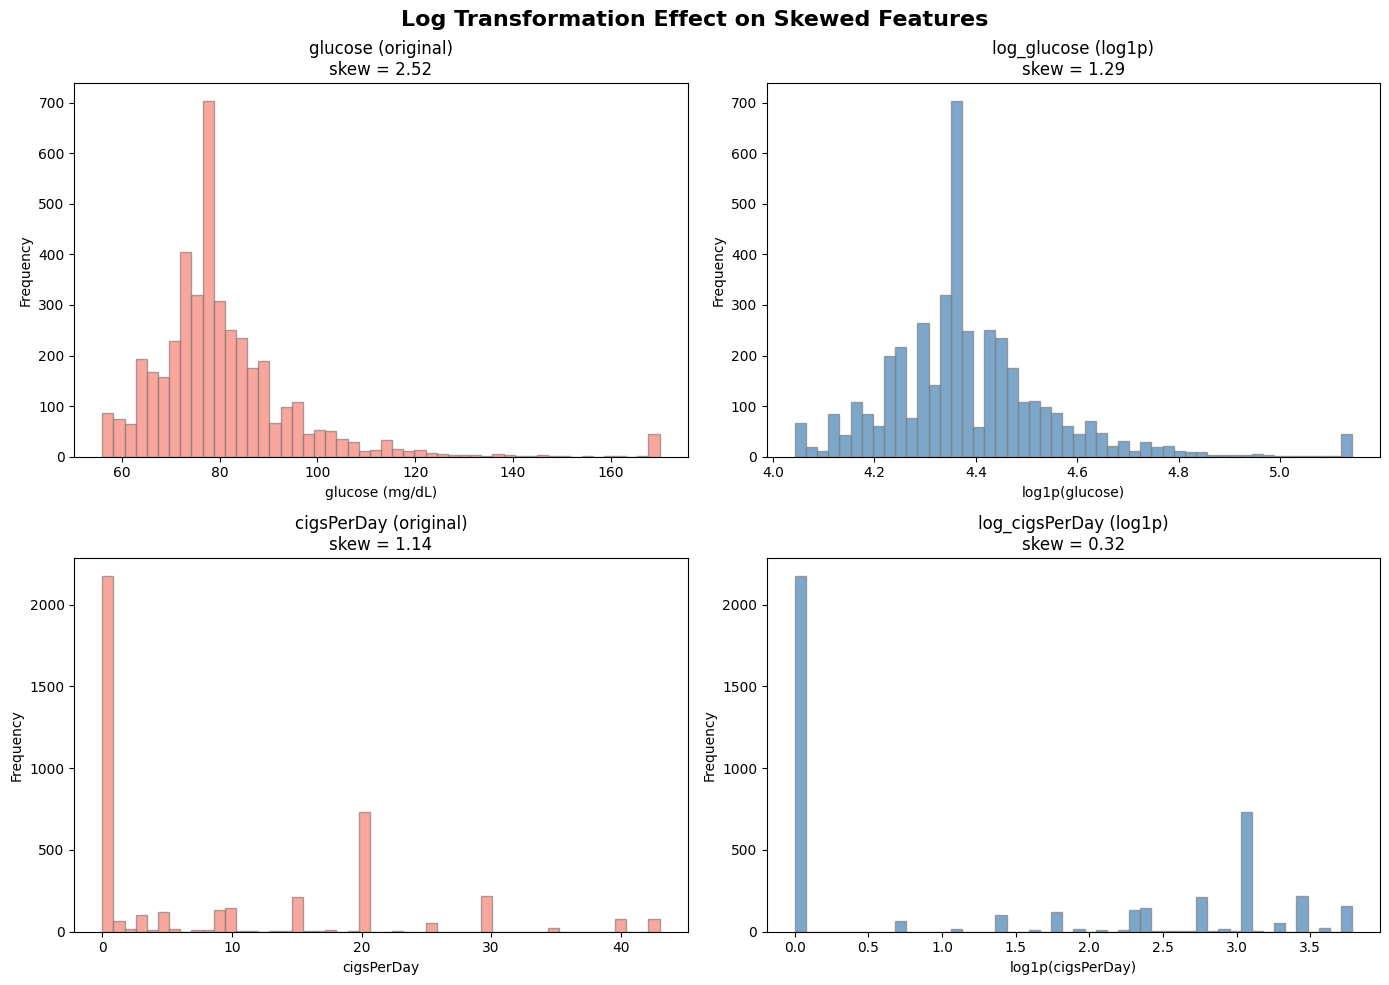

In [164]:
# ============================================================
# 5.2 Verify log transforms addressed the skewness
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Log Transformation Effect on Skewed Features', fontsize=16, fontweight='bold')

# glucose — before vs after
axes[0, 0].hist(df_clean_data['glucose'], bins=50, color='salmon', alpha=0.7, edgecolor='gray')
axes[0, 0].set_title(f"glucose (original)\nskew = {df_clean_data['glucose'].skew():.2f}")
axes[0, 0].set_xlabel('glucose (mg/dL)')

axes[0, 1].hist(df_clean_data['log_glucose'], bins=50, color='steelblue', alpha=0.7, edgecolor='gray')
axes[0, 1].set_title(f"log_glucose (log1p)\nskew = {df_clean_data['log_glucose'].skew():.2f}")
axes[0, 1].set_xlabel('log1p(glucose)')

# cigsPerDay — before vs after
axes[1, 0].hist(df_clean_data['cigsPerDay'], bins=50, color='salmon', alpha=0.7, edgecolor='gray')
axes[1, 0].set_title(f"cigsPerDay (original)\nskew = {df_clean_data['cigsPerDay'].skew():.2f}")
axes[1, 0].set_xlabel('cigsPerDay')

axes[1, 1].hist(df_clean_data['log_cigsPerDay'], bins=50, color='steelblue', alpha=0.7, edgecolor='gray')
axes[1, 1].set_title(f"log_cigsPerDay (log1p)\nskew = {df_clean_data['log_cigsPerDay'].skew():.2f}")
axes[1, 1].set_xlabel('log1p(cigsPerDay)')

for ax in axes.flat:
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('Visualizations/1_log_transform_skewness.png', dpi=150, bbox_inches='tight')
plt.show()

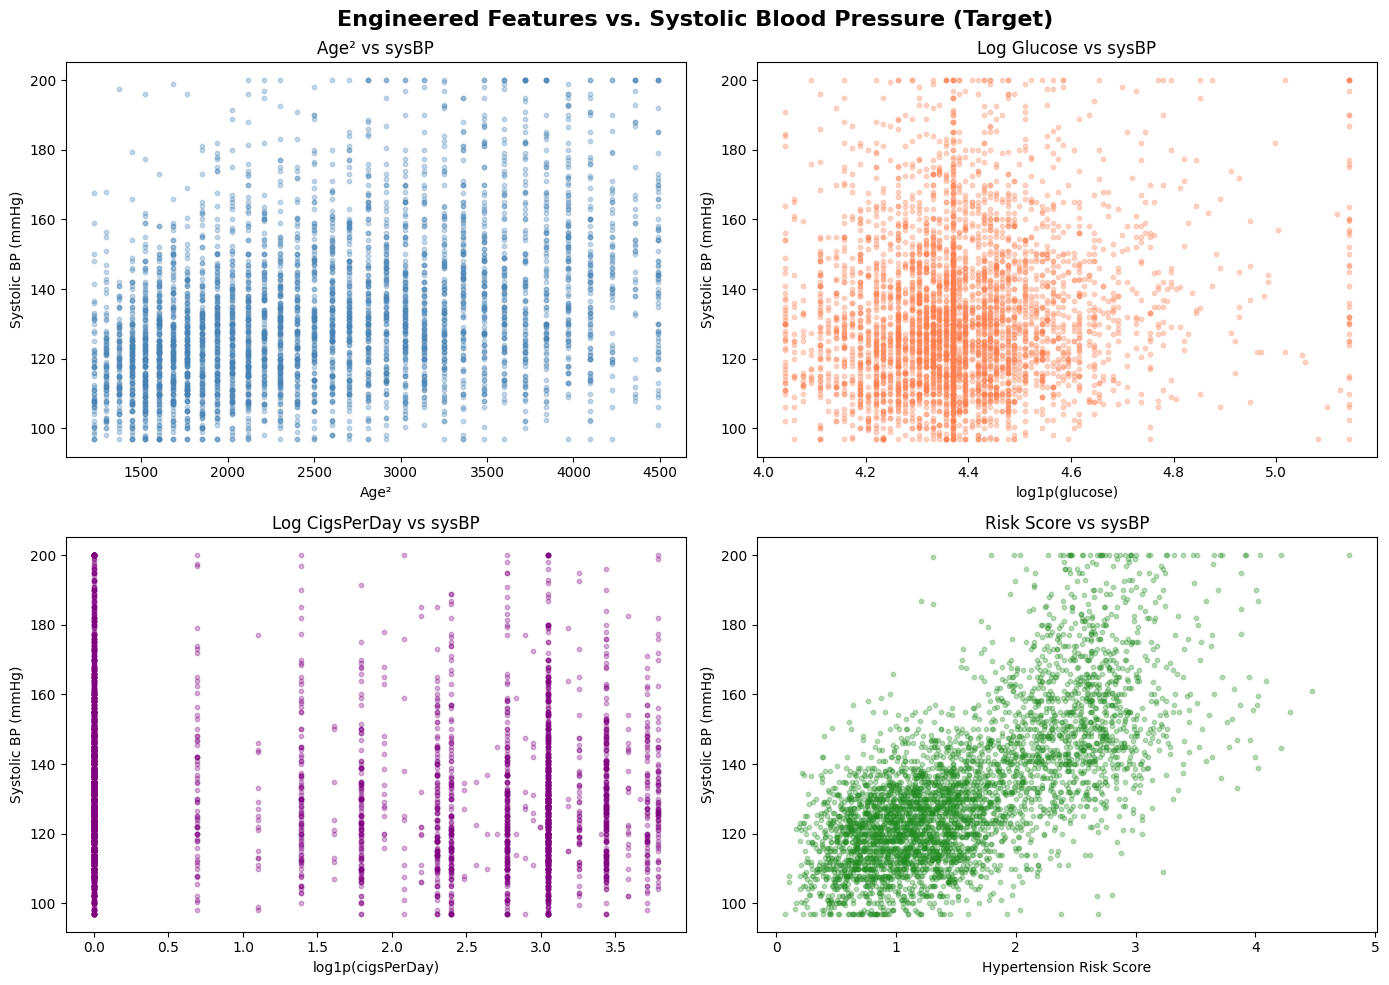

In [165]:
# ============================================================
# 5.3 Visualize Engineered Features vs Target (sysBP)
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Engineered Features vs. Systolic Blood Pressure (Target)',
             fontsize=16, fontweight='bold')

# Age Squared vs sysBP
axes[0, 0].scatter(df_clean_data['age_squared'], df_clean_data['sysBP'],
                   alpha=0.3, s=10, color='steelblue')
axes[0, 0].set_xlabel('Age²')
axes[0, 0].set_ylabel('Systolic BP (mmHg)')
axes[0, 0].set_title('Age² vs sysBP')

# Log Glucose vs sysBP
axes[0, 1].scatter(df_clean_data['log_glucose'], df_clean_data['sysBP'],
                   alpha=0.3, s=10, color='coral')
axes[0, 1].set_xlabel('log1p(glucose)')
axes[0, 1].set_ylabel('Systolic BP (mmHg)')
axes[0, 1].set_title('Log Glucose vs sysBP')

# Log CigsPerDay vs sysBP
axes[1, 0].scatter(df_clean_data['log_cigsPerDay'], df_clean_data['sysBP'],
                   alpha=0.3, s=10, color='purple')
axes[1, 0].set_xlabel('log1p(cigsPerDay)')
axes[1, 0].set_ylabel('Systolic BP (mmHg)')
axes[1, 0].set_title('Log CigsPerDay vs sysBP')

# Hypertension Risk Score vs sysBP
axes[1, 1].scatter(df_clean_data['hypertension_risk_score'], df_clean_data['sysBP'],
                   alpha=0.3, s=10, color='forestgreen')
axes[1, 1].set_xlabel('Hypertension Risk Score')
axes[1, 1].set_ylabel('Systolic BP (mmHg)')
axes[1, 1].set_title('Risk Score vs sysBP')

plt.tight_layout()
plt.savefig('Visualizations/2_engineered_features_vs_target.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Feature Selection and Data Preparation

I define the predictor variables (X) and the target variable (y = `sysBP`), then split into training and test sets with standardization.

**Exclusions from predictor set:**
- `sysBP` — the target variable itself
- `diaBP` — highly correlated with sysBP by physiological definition; including it would inflate R² artificially
- `TenYearCHD` — binary outcome from a different prediction task; not a legitimate predictor of blood pressure
- `glucose` and `cigsPerDay` (originals) — replaced by their log-transformed versions

In [166]:
# ============================================================
# 6.1 Define Features and Target
# ============================================================
target = 'sysBP'
y = df_clean_data[target].copy()

# Exclude target, leaky/collinear features, and originals replaced by log versions
exclude_cols = ['sysBP', 'diaBP', 'TenYearCHD', 'glucose', 'cigsPerDay', 'CHD_Label']
feature_cols = [col for col in df_clean_data.columns if col not in exclude_cols]

X = df_clean_data[feature_cols].copy()

print(f"Target variable: {target}")
print(f"Number of predictor features: {len(feature_cols)}")
print(f"\nFeature list:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")
print(f"\nTarget distribution:")
print(y.describe())

Target variable: sysBP
Number of predictor features: 15

Feature list:
   1. male
   2. age
   3. education
   4. currentSmoker
   5. BPMeds
   6. prevalentStroke
   7. prevalentHyp
   8. diabetes
   9. totChol
  10. BMI
  11. heartRate
  12. log_glucose
  13. log_cigsPerDay
  14. age_squared
  15. hypertension_risk_score

Target distribution:
count    4240.000000
mean      132.242217
std        21.409320
min        97.000000
25%       117.000000
50%       128.000000
75%       144.000000
max       200.000000
Name: sysBP, dtype: float64


In [167]:
# ============================================================
# 6.2 Train-Test Split (80/20, random_state=42)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Training set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:     {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTraining target — Mean: {y_train.mean():.2f}, Std: {y_train.std():.2f}")
print(f"Test target     — Mean: {y_test.mean():.2f}, Std: {y_test.std():.2f}")

Training set: 3,392 samples (80.0%)
Test set:     848 samples (20.0%)

Training target — Mean: 132.34, Std: 21.61
Test target     — Mean: 131.85, Std: 20.61


In [168]:
# ============================================================
# 6.3 Feature Scaling (Standardization)
# ============================================================
# StandardScaler: zero mean, unit variance
# Important for regularized models (Ridge, Lasso) —
# coefficients penalized equally only if features are on the same scale.
# Fit on training data only; transform both train and test.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames for interpretability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=feature_cols, index=X_test.index)

print("Feature scaling complete (StandardScaler).")
print(f"Training features: {X_train_scaled.shape}")
print(f"Test features:     {X_test_scaled.shape}")

Feature scaling complete (StandardScaler).
Training features: (3392, 15)
Test features:     (848, 15)


## 7. Correlation Analysis

Before modeling, I examine how each predictor correlates with the target variable `sysBP`. This validates the feature engineering decisions and sets expectations for model performance.

In [169]:
# ============================================================
# 7.1 Correlation with Target Variable
# ============================================================
correlations = X_train.corrwith(y_train).sort_values(ascending=False)

print("Feature correlations with sysBP (sorted by absolute value):")
print("=" * 55)
for feat, corr in correlations.abs().sort_values(ascending=False).items():
    direction = "+" if correlations[feat] > 0 else "-"
    print(f"  {feat:30s}  {direction}{corr:.4f}")

Feature correlations with sysBP (sorted by absolute value):
  prevalentHyp                    +0.7099
  hypertension_risk_score         +0.6991
  age                             +0.3977
  age_squared                     +0.3967
  BMI                             +0.3269
  BPMeds                          +0.2571
  totChol                         +0.1992
  heartRate                       +0.1939
  education                       -0.1338
  log_glucose                     +0.1295
  currentSmoker                   -0.1212
  diabetes                        +0.1149
  log_cigsPerDay                  -0.1143
  male                            -0.0509
  prevalentStroke                 +0.0428


## 8. Regression Model Building

I build and compare three regression models:

| Model | Description | Key Property |
|-------|-------------|-------------|
| **Linear Regression** | Ordinary Least Squares (OLS) — no regularization | Baseline model |
| **Ridge Regression** | L2 regularization — penalizes large coefficients | Handles multicollinearity |
| **Lasso Regression** | L1 regularization — can zero out coefficients | Built-in feature selection |

All models use the standardized features to ensure fair comparison, especially since regularized models are sensitive to feature scaling.

In [170]:
# ============================================================
# 8.1 Define Models
# ============================================================
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression (α=1.0)': Ridge(alpha=1.0, random_state=42),
    'Lasso Regression (α=0.1)': Lasso(alpha=0.1, random_state=42, max_iter=10000)
}

print("Models to be trained:")
for i, (name, model) in enumerate(models.items(), 1):
    print(f"  {i}. {name}")

Models to be trained:
  1. Linear Regression
  2. Ridge Regression (α=1.0)
  3. Lasso Regression (α=0.1)


In [171]:
# ============================================================
# 8.2 Train All Models and Collect Evaluation Metrics
# ============================================================
results = {}

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)

    # Predict on both sets
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    # Evaluation metrics
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    # Adjusted R² (test set)
    n = X_test_scaled.shape[0]
    p = X_test_scaled.shape[1]
    adj_r2 = 1 - (1 - test_r2) * (n - 1) / (n - p - 1)

    test_mse = mean_squared_error(y_test, y_test_pred)
    test_rmse = np.sqrt(test_mse)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    results[name] = {
        'model': model,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'adj_r2': adj_r2,
        'mse': test_mse,
        'rmse': test_rmse,
        'mae': test_mae,
        'y_test_pred': y_test_pred
    }

    print(f"\n{'=' * 60}")
    print(f"  {name}")
    print(f"{'=' * 60}")
    print(f"  Train R²:      {train_r2:.4f}")
    print(f"  Test R²:       {test_r2:.4f}")
    print(f"  Adjusted R²:   {adj_r2:.4f}")
    print(f"  MSE:           {test_mse:.4f}")
    print(f"  RMSE:          {test_rmse:.4f}")
    print(f"  MAE:           {test_mae:.4f}")


  Linear Regression
  Train R²:      0.5666
  Test R²:       0.5392
  Adjusted R²:   0.5309
  MSE:           195.4455
  RMSE:          13.9802
  MAE:           10.6640

  Ridge Regression (α=1.0)
  Train R²:      0.5666
  Test R²:       0.5392
  Adjusted R²:   0.5309
  MSE:           195.4386
  RMSE:          13.9799
  MAE:           10.6638

  Lasso Regression (α=0.1)
  Train R²:      0.5663
  Test R²:       0.5411
  Adjusted R²:   0.5329
  MSE:           194.6328
  RMSE:          13.9511
  MAE:           10.6468


## 9. Model Evaluation and Comparison

### 9.1 Summary Comparison Table

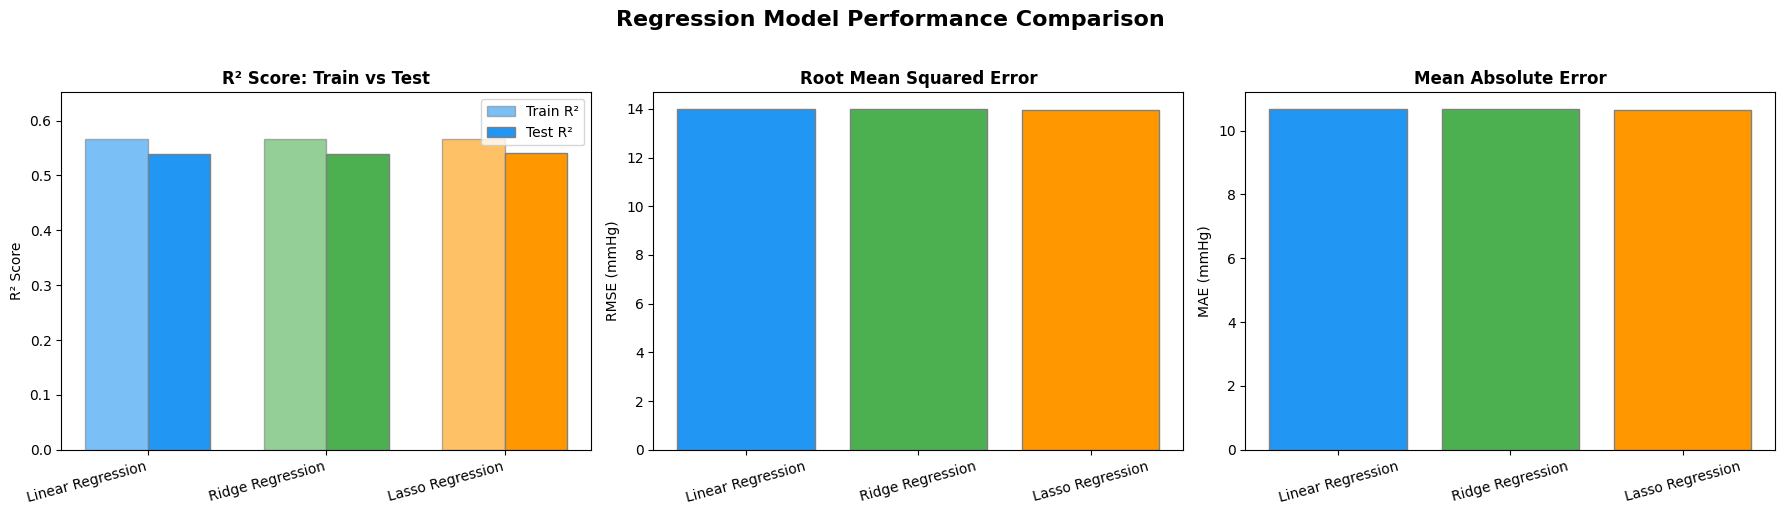

In [172]:
# ============================================================
# 9.2 Bar Chart — Model Performance Metrics
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_names_short = [name.split('(')[0].strip() for name in results.keys()]
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

# R² Comparison (Train vs Test)
x = np.arange(len(model_names_short))
width = 0.35
axes[0].bar(x - width/2, [r['train_r2'] for r in results.values()], width,
            label='Train R²', color=colors, alpha=0.6, edgecolor='gray')
axes[0].bar(x + width/2, [r['test_r2'] for r in results.values()], width,
            label='Test R²', color=colors, alpha=1.0, edgecolor='gray')
axes[0].set_ylabel('R² Score')
axes[0].set_title('R² Score: Train vs Test', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names_short, rotation=15, ha='right')
axes[0].legend()
axes[0].set_ylim(0, max([r['train_r2'] for r in results.values()]) * 1.15)

# RMSE Comparison
axes[1].bar(model_names_short, [r['rmse'] for r in results.values()],
            color=colors, edgecolor='gray')
axes[1].set_ylabel('RMSE (mmHg)')
axes[1].set_title('Root Mean Squared Error', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

# MAE Comparison
axes[2].bar(model_names_short, [r['mae'] for r in results.values()],
            color=colors, edgecolor='gray')
axes[2].set_ylabel('MAE (mmHg)')
axes[2].set_title('Mean Absolute Error', fontweight='bold')
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('Regression Model Performance Comparison',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Visualizations/3_model_comparison_metrics.png', dpi=150, bbox_inches='tight')
plt.show()


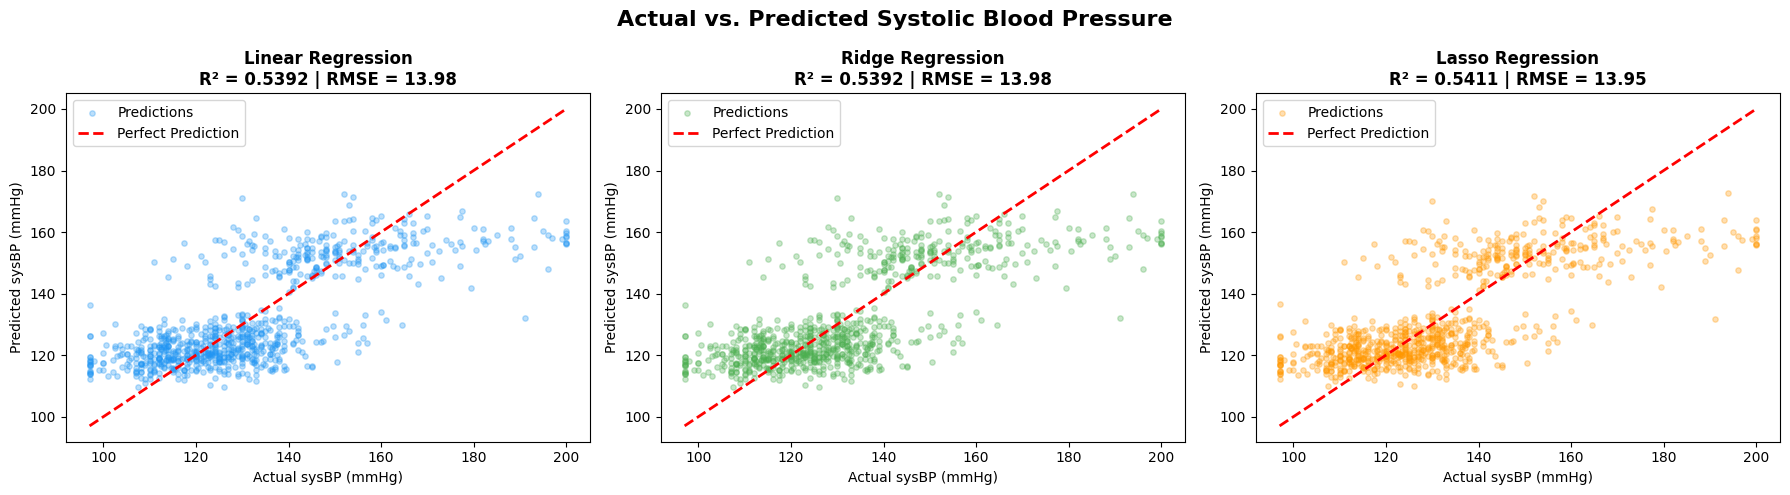

Figure saved: Visualizations/4_actual_vs_predicted.png


In [173]:
# ============================================================
# 9.3 Actual vs Predicted Scatter Plots
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes_flat = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    ax = axes_flat[i]
    short_name = name.split('(')[0].strip()

    ax.scatter(y_test, res['y_test_pred'], alpha=0.3, s=15, color=colors[i],
               label='Predictions')

    # Perfect prediction line
    min_val = min(y_test.min(), res['y_test_pred'].min())
    max_val = max(y_test.max(), res['y_test_pred'].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2,
            label='Perfect Prediction')

    ax.set_xlabel('Actual sysBP (mmHg)')
    ax.set_ylabel('Predicted sysBP (mmHg)')
    ax.set_title(f'{short_name}\nR² = {res["test_r2"]:.4f} | RMSE = {res["rmse"]:.2f}',
                 fontweight='bold')
    ax.legend(loc='upper left')

plt.suptitle('Actual vs. Predicted Systolic Blood Pressure',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('Visualizations/4_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: Visualizations/4_actual_vs_predicted.png")

## 10. Cross-Validation

I use **10-fold cross-validation** to assess each model's ability to generalize to unseen data. Cross-validation provides a more robust performance estimate than a single train-test split by evaluating the model across 10 different data partitions — each fold serves as a held-out test set exactly once.

In [174]:
# ============================================================
# 10.1 K-Fold Cross-Validation (k=10)
# ============================================================
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# Scale the full dataset for cross-validation
X_full_scaled = StandardScaler().fit_transform(X)
y_full = y.values

cv_results = {}

print("10-Fold Cross-Validation Results")
print("=" * 75)
print(f"  {'Model':<35} {'Mean R²':>10} {'Std R²':>10} {'Mean RMSE':>12} {'Std RMSE':>10}")
print("  " + "-" * 72)

for name, model_template in models.items():
    # R² scores across 10 folds
    r2_scores = cross_val_score(model_template, X_full_scaled, y_full,
                                cv=kf, scoring='r2')

    # RMSE scores (sklearn returns neg_MSE; convert to RMSE)
    neg_mse_scores = cross_val_score(model_template, X_full_scaled, y_full,
                                     cv=kf, scoring='neg_mean_squared_error')
    rmse_scores = np.sqrt(-neg_mse_scores)

    cv_results[name] = {
        'r2_scores': r2_scores,
        'r2_mean': r2_scores.mean(),
        'r2_std': r2_scores.std(),
        'rmse_scores': rmse_scores,
        'rmse_mean': rmse_scores.mean(),
        'rmse_std': rmse_scores.std()
    }

    short_name = name.split('(')[0].strip()
    print(f"  {short_name:<35} {r2_scores.mean():>10.4f} {r2_scores.std():>10.4f} "
          f"{rmse_scores.mean():>12.4f} {rmse_scores.std():>10.4f}")

print("  " + "-" * 72)
best_cv = max(cv_results.items(), key=lambda x: x[1]['r2_mean'])
print(f"\n  Best CV model: {best_cv[0].split('(')[0].strip()} "
      f"(Mean R² = {best_cv[1]['r2_mean']:.4f} ± {best_cv[1]['r2_std']:.4f})")

10-Fold Cross-Validation Results
  Model                                  Mean R²     Std R²    Mean RMSE   Std RMSE
  ------------------------------------------------------------------------
  Linear Regression                       0.5564     0.0320      14.2161     0.2772
  Ridge Regression                        0.5565     0.0320      14.2158     0.2771
  Lasso Regression                        0.5567     0.0310      14.2137     0.2762
  ------------------------------------------------------------------------

  Best CV model: Lasso Regression (Mean R² = 0.5567 ± 0.0310)


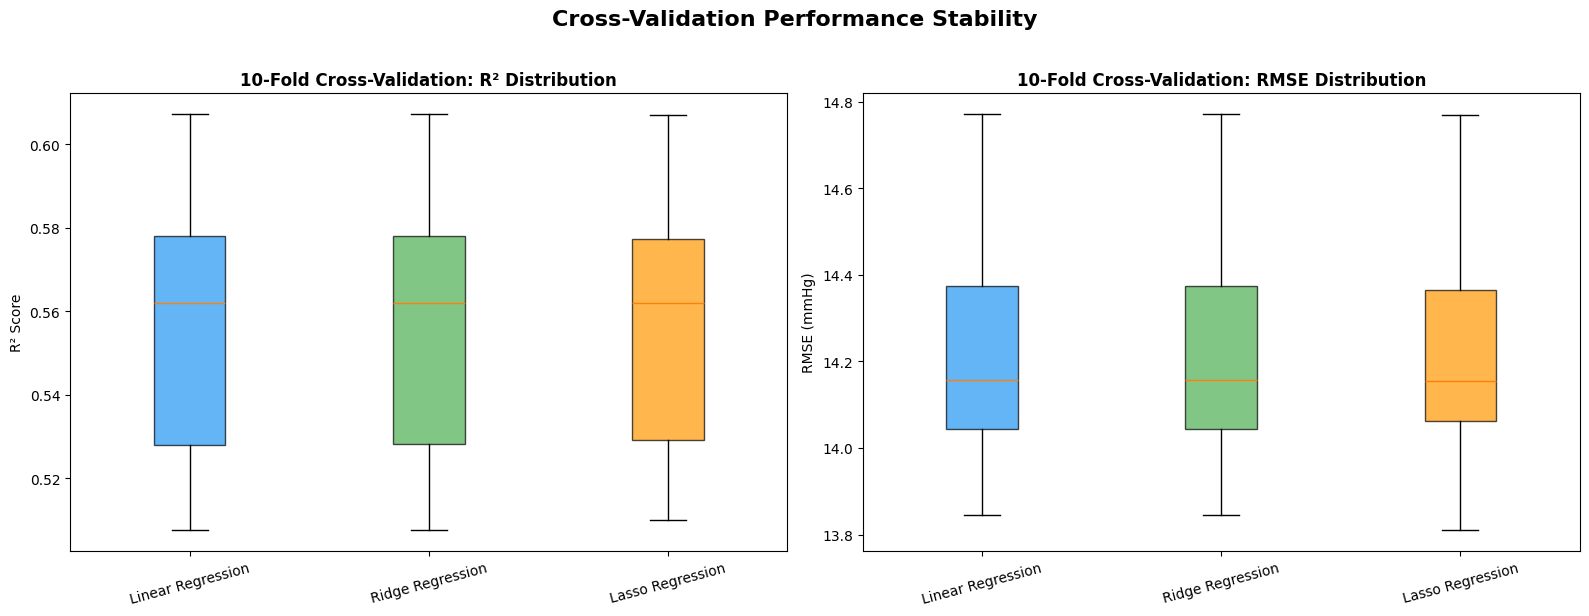

In [175]:
# ============================================================
# 10.2 Cross-Validation Box Plots
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_short_names = [name.split('(')[0].strip() for name in cv_results.keys()]

# R² Box Plot
r2_data = [cv['r2_scores'] for cv in cv_results.values()]
bp1 = axes[0].boxplot(r2_data, labels=model_short_names, patch_artist=True)
for patch, color in zip(bp1['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_ylabel('R² Score')
axes[0].set_title('10-Fold Cross-Validation: R² Distribution', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

# RMSE Box Plot
rmse_data = [cv['rmse_scores'] for cv in cv_results.values()]
bp2 = axes[1].boxplot(rmse_data, labels=model_short_names, patch_artist=True)
for patch, color in zip(bp2['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_ylabel('RMSE (mmHg)')
axes[1].set_title('10-Fold Cross-Validation: RMSE Distribution', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Cross-Validation Performance Stability',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Visualizations/5_cross_validation_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. Feature Importance Analysis

I examine the standardized regression coefficients across all four models. Since all features were standardized before fitting, the coefficients are directly comparable — larger absolute values indicate stronger contributions to predicting sysBP. For Lasso, coefficients driven to exactly zero indicate features that Lasso eliminated during its built-in feature selection.

In [176]:
# ============================================================
# 11.1 Feature Coefficients Comparison Table
# ============================================================
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Linear': results['Linear Regression']['model'].coef_,
    'Ridge': results['Ridge Regression (α=1.0)']['model'].coef_,
    'Lasso': results['Lasso Regression (α=0.1)']['model'].coef_
})

# Sort by absolute value of Linear Regression coefficients
coef_df['abs_linear'] = coef_df['Linear'].abs()
coef_df = coef_df.sort_values('abs_linear', ascending=False).drop('abs_linear', axis=1)

print("Feature Coefficients (Standardized — sorted by |Linear| coefficient)")
print("=" * 85)
print(coef_df.to_string(index=False, float_format='{:.4f}'.format))

# Lasso feature selection summary
lasso_selected = (coef_df['Lasso'] != 0).sum()
lasso_zeroed = (coef_df['Lasso'] == 0).sum()
print(f"\nLasso feature selection: {lasso_selected} features retained, "
      f"{lasso_zeroed} features zeroed out")
if lasso_zeroed > 0:
    zeroed_feats = coef_df[coef_df['Lasso'] == 0]['Feature'].tolist()
    print(f"  Zeroed features: {zeroed_feats}")

Feature Coefficients (Standardized — sorted by |Linear| coefficient)
                Feature  Linear   Ridge   Lasso
           prevalentHyp  9.2199  9.2258 10.8006
hypertension_risk_score  5.7687  5.7530  2.9893
                    age  1.7805  1.7133  2.4911
              heartRate  1.7513  1.7512  1.6986
                 BPMeds  1.4622  1.4623  1.3761
               diabetes -0.8746 -0.8708 -0.1049
                    BMI  0.8439  0.8483  1.4119
                totChol -0.7711 -0.7656  0.0000
                   male -0.7373 -0.7371 -0.6055
              education -0.7313 -0.7311 -0.6587
            log_glucose  0.5946  0.5944  0.4217
          currentSmoker  0.1461  0.1457  0.0000
        prevalentStroke -0.1149 -0.1148 -0.0041
            age_squared  0.0734  0.1462  0.1912
         log_cigsPerDay  0.0133  0.0138  0.0000

Lasso feature selection: 12 features retained, 3 features zeroed out
  Zeroed features: ['totChol', 'currentSmoker', 'log_cigsPerDay']


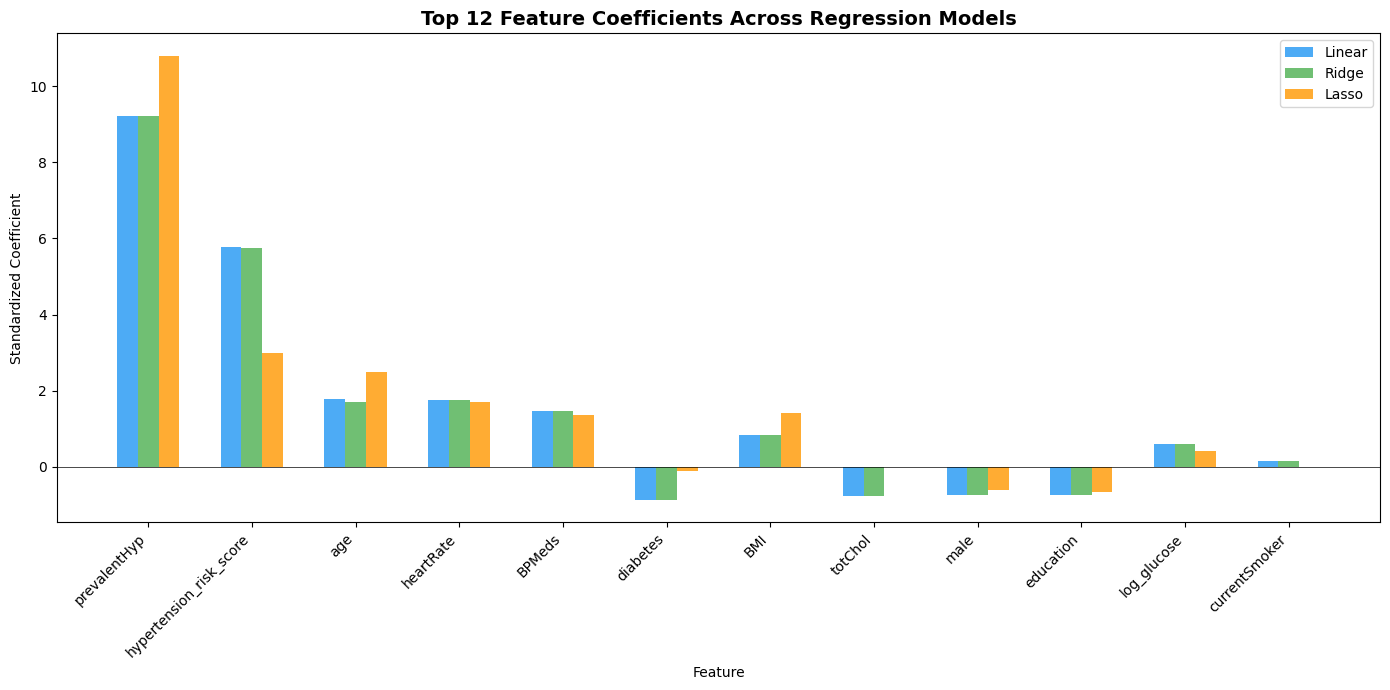

In [177]:
# ============================================================
# 11.2 Top Feature Importance Bar Chart
# ============================================================
top_n = 12
coef_plot = coef_df.head(top_n).copy()

fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(coef_plot))
width = 0.2

ax.bar(x - width, coef_plot['Linear'], width, label='Linear',
       color=colors[0], alpha=0.8)
ax.bar(x, coef_plot['Ridge'], width, label='Ridge',
       color=colors[1], alpha=0.8)
ax.bar(x + width, coef_plot['Lasso'], width, label='Lasso',
       color=colors[2], alpha=0.8)

ax.set_xlabel('Feature')
ax.set_ylabel('Standardized Coefficient')
ax.set_title(f'Top {top_n} Feature Coefficients Across Regression Models',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(coef_plot['Feature'], rotation=45, ha='right')
ax.legend()
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig('Visualizations/6_feature_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Regularization Analysis

I explore how the regularization strength (alpha) affects cross-validated R² for Ridge and Lasso. This visualizes the bias-variance trade-off: too little regularization risks overfitting, too much underfits by shrinking all coefficients toward zero.

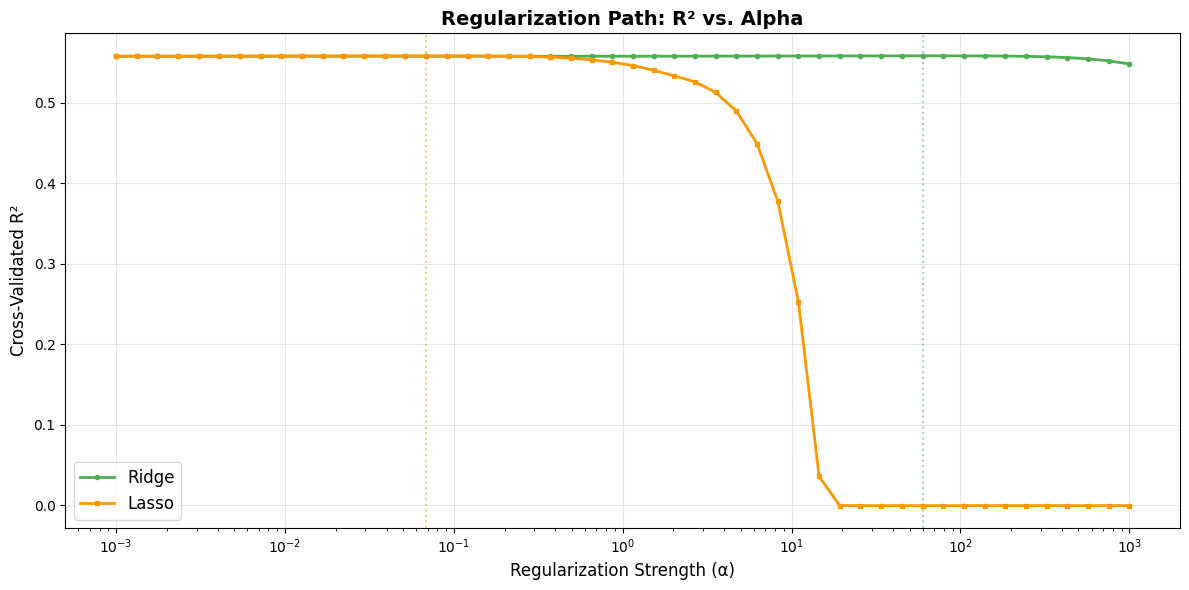

Optimal alpha — Ridge: 59.6362, Lasso: 0.0687


In [178]:
# ============================================================
# 12.1 Regularization Path — R² vs Alpha
# ============================================================
alphas = np.logspace(-3, 3, 50)

ridge_scores = []
lasso_scores = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha, random_state=42)
    ridge_cv = cross_val_score(ridge, X_full_scaled, y_full, cv=5, scoring='r2')
    ridge_scores.append(ridge_cv.mean())

    lasso = Lasso(alpha=alpha, random_state=42, max_iter=10000)
    lasso_cv = cross_val_score(lasso, X_full_scaled, y_full, cv=5, scoring='r2')
    lasso_scores.append(lasso_cv.mean())


fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(alphas, ridge_scores, '-o', markersize=3, label='Ridge',
        color=colors[1], linewidth=2)
ax.plot(alphas, lasso_scores, '-s', markersize=3, label='Lasso',
        color=colors[2], linewidth=2)

ax.set_xscale('log')
ax.set_xlabel('Regularization Strength (α)', fontsize=12)
ax.set_ylabel('Cross-Validated R²', fontsize=12)
ax.set_title('Regularization Path: R² vs. Alpha', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Mark optimal alpha for each
best_ridge_alpha = alphas[np.argmax(ridge_scores)]
best_lasso_alpha = alphas[np.argmax(lasso_scores)]
ax.axvline(x=best_ridge_alpha, color=colors[1], linestyle=':', alpha=0.5)
ax.axvline(x=best_lasso_alpha, color=colors[2], linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('Visualizations/7_regularization_path.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Optimal alpha — Ridge: {best_ridge_alpha:.4f}, "
      f"Lasso: {best_lasso_alpha:.4f}")


## Project Deliverable 3 : Classification, Clustering, and Pattern Mining

## 13. Classification

### 13.1 Setting Up Features and Splitting the Data

I am using `TenYearCHD` as the target variable. The features include the original columns plus the ones I engineered in Deliverable 2.

One thing I noticed is that the dataset is imbalanced — only about 15% of patients actually developed CHD. This means if the model just always predicted 'No CHD', it would still get ~85% accuracy without actually learning anything useful. To deal with this, I used `class_weight='balanced'` in the Decision Tree and I will also focus on F1 score as a better measure of performance.

In [179]:
# Pulse pressure — valid here since sysBP is a predictor, not the target
# Systolic BP - Diastolic BP
df_clean_data['pulse_pressure'] = df_clean_data['sysBP'] - df_clean_data['diaBP']
print(f"pulse_pressure    — Mean: {df_clean_data['pulse_pressure'].mean():.2f}")

print(f"\nDataset shape after feature engineering: {df_clean_data.shape}")
print(f"Target variable distribution:")
print(df_clean_data['TenYearCHD'].value_counts())

pulse_pressure    — Mean: 49.40

Dataset shape after feature engineering: (4240, 22)
Target variable distribution:
TenYearCHD
0    3596
1     644
Name: count, dtype: int64


In [180]:
feature_cols = [
    'male', 'age', 'currentSmoker', 'cigsPerDay', 'BPMeds',
    'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol',
    'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose',
    'log_glucose', 'log_cigsPerDay', 'age_squared',
    'pulse_pressure', 'hypertension_risk_score'
]

X = df_clean_data[feature_cols]
y = df_clean_data['TenYearCHD']

# 80/20 split, stratified to keep class proportions the same in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# y_train.value_counts()

# # # Scale the features
scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),      columns=feature_cols)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"\nClass balance (train) — No CHD: {(y_train==0).sum()}  CHD: {(y_train==1).sum()}")
print(f"Class balance (test)  — No CHD: {(y_test==0).sum()}   CHD: {(y_test==1).sum()}")

Training samples : 3392
Test samples     : 848

Class balance (train) — No CHD: 2877  CHD: 515
Class balance (test)  — No CHD: 719   CHD: 129


### 13.2 Model 1 — Decision Tree

I chose a Decision Tree because it is easy to understand and visualize. It works by asking a series of yes/no questions about the features to arrive at a prediction. I set `max_depth=5` as a starting point to prevent the tree from getting too complex.

In [181]:
# Train a baseline Decision Tree
dt_base = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    class_weight='balanced',
    random_state=42
)
dt_base.fit(X_train_sc, y_train)

y_pred_dt  = dt_base.predict(X_test_sc)
y_proba_dt = dt_base.predict_proba(X_test_sc)[:, 1]

acc_dt = accuracy_score(y_test, y_pred_dt)
f1_dt  = f1_score(y_test, y_pred_dt)
auc_dt = roc_auc_score(y_test, y_proba_dt)

print("=== Decision Tree (Baseline) ===")
print(f"Accuracy : {acc_dt:.4f}")
print(f"F1 Score : {f1_dt:.4f}")
print(f"ROC-AUC  : {auc_dt:.4f}")
print()
print(classification_report(y_test, y_pred_dt, target_names=['No CHD', 'CHD']))

=== Decision Tree (Baseline) ===
Accuracy : 0.5943
F1 Score : 0.3202
ROC-AUC  : 0.6224

              precision    recall  f1-score   support

      No CHD       0.90      0.59      0.71       719
         CHD       0.21      0.63      0.32       129

    accuracy                           0.59       848
   macro avg       0.56      0.61      0.52       848
weighted avg       0.79      0.59      0.65       848



### 13.3 Hyperparameter Tuning — Decision Tree

To try to improve the baseline model, I used GridSearchCV to test different combinations of settings. It goes through every combination using 5-fold cross-validation and picks the one that gives the best F1 score.

The parameters I tuned:
- `max_depth` — how deep the tree can grow
- `min_samples_split` — how many samples are needed before splitting a node
- `min_samples_leaf` — minimum samples at a leaf node
- `criterion` — Gini or Entropy for split decisions

In [182]:
param_grid = {
    'max_depth'        : [3, 5, 7, 10],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf' : [5, 10, 20],
    'criterion'        : ['gini', 'entropy']
}

# Using StratifiedKFold validation as dataset is not balanced
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)
grid_search.fit(X_train_sc, y_train)

print("Best Parameters Found:", grid_search.best_params_)
print(f"Best CV F1 Score     : {grid_search.best_score_:.4f}")

Best Parameters Found: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 10}
Best CV F1 Score     : 0.3490


In [183]:
# Test the tuned model
dt_tuned = grid_search.best_estimator_
y_pred_dt_tuned  = dt_tuned.predict(X_test_sc)
y_proba_dt_tuned = dt_tuned.predict_proba(X_test_sc)[:, 1]

acc_dt_tuned = accuracy_score(y_test, y_pred_dt_tuned)
f1_dt_tuned  = f1_score(y_test, y_pred_dt_tuned)
auc_dt_tuned = roc_auc_score(y_test, y_proba_dt_tuned)

print("=== Decision Tree (Tuned) ===")
print(f"Accuracy : {acc_dt_tuned:.4f}")
print(f"F1 Score : {f1_dt_tuned:.4f}")
print(f"ROC-AUC  : {auc_dt_tuned:.4f}")
print()
print(classification_report(y_test, y_pred_dt_tuned, target_names=['No CHD', 'CHD']))

=== Decision Tree (Tuned) ===
Accuracy : 0.5507
F1 Score : 0.3280
ROC-AUC  : 0.6511

              precision    recall  f1-score   support

      No CHD       0.91      0.52      0.66       719
         CHD       0.21      0.72      0.33       129

    accuracy                           0.55       848
   macro avg       0.56      0.62      0.50       848
weighted avg       0.81      0.55      0.61       848



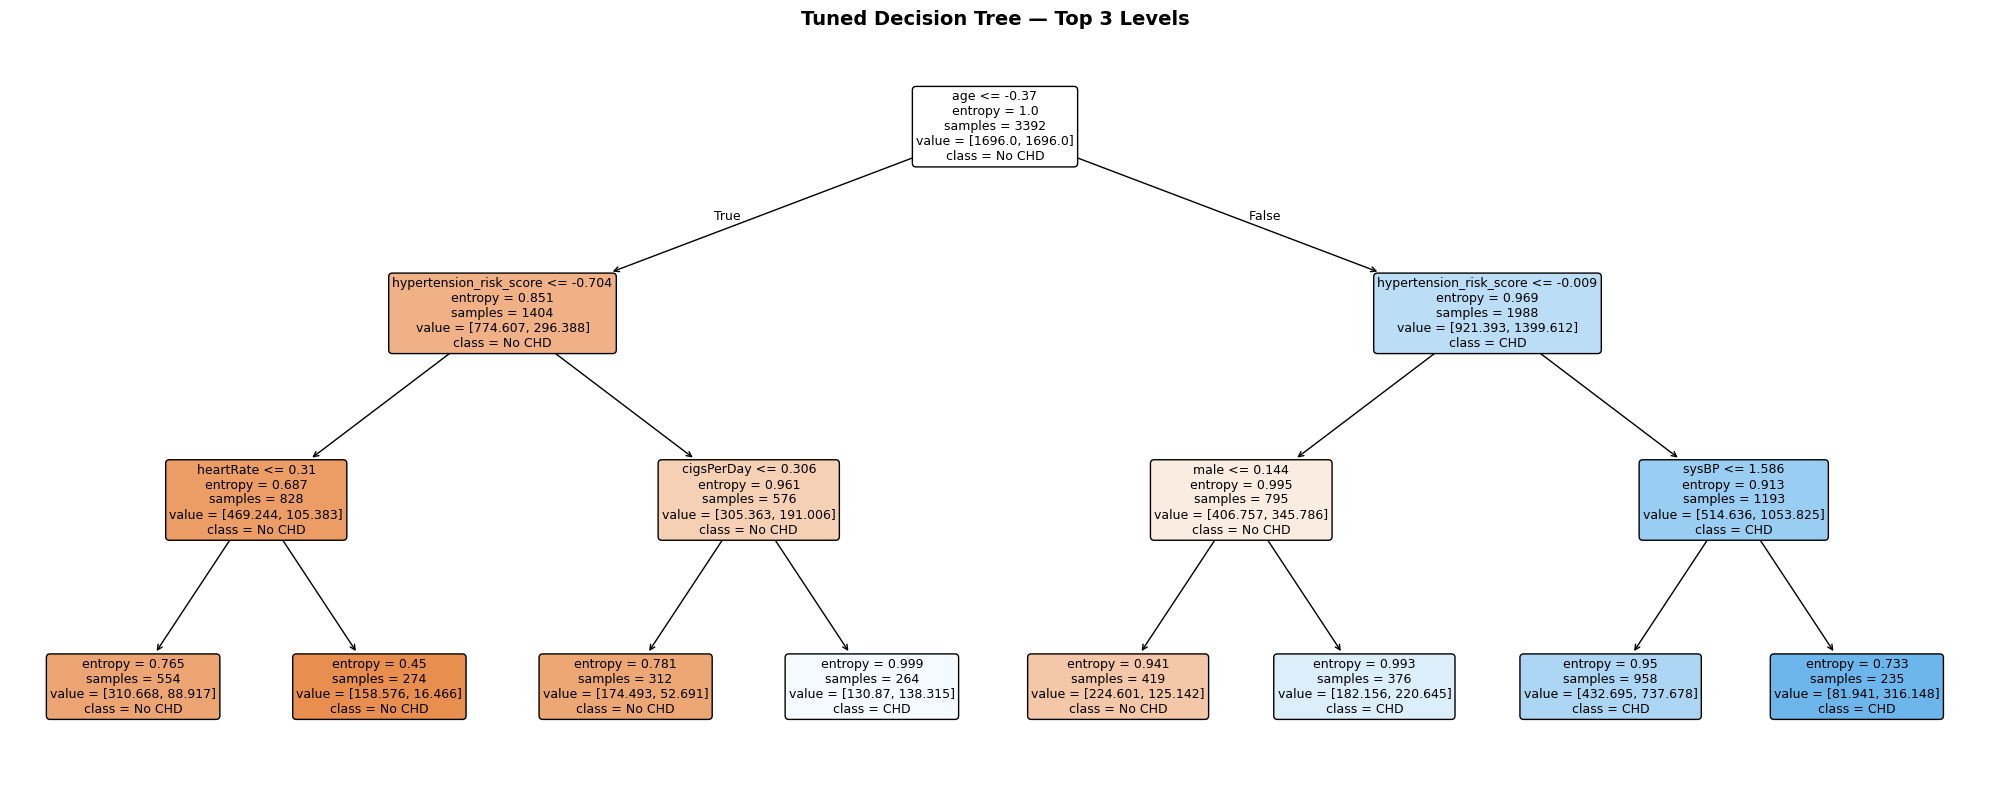

In [184]:
# Show the top 3 levels of the tuned tree
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dt_tuned,
    max_depth=3,
    feature_names=feature_cols,
    class_names=['No CHD', 'CHD'],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)
ax.set_title('Tuned Decision Tree — Top 3 Levels', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Visualizations/1_dt_tree_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

### 13.4 Model 2 — k-Nearest Neighbors (k-NN)

For my second model I chose k-NN. The idea is simple — to predict a patient's CHD risk, it looks at the k most similar patients in the training data and takes a majority vote. I used `weights='distance'` so that closer neighbors have more say in the prediction.

To find the best k, I tested odd values from 3 to 29 using cross-validation.

Best k : 5  (CV F1 = 0.2024)


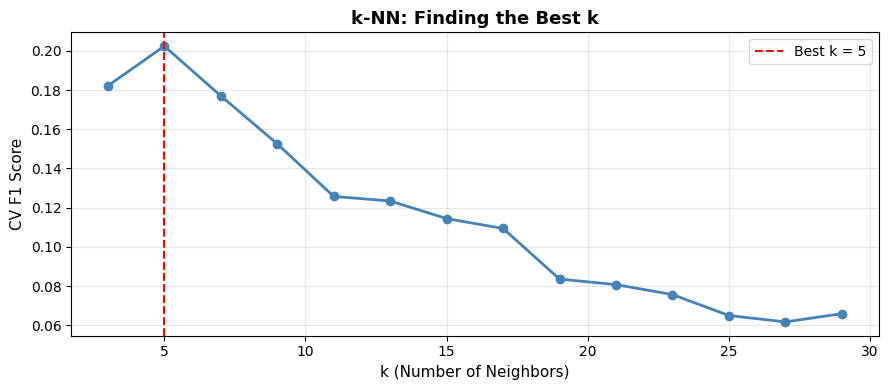

In [185]:
# Try different values of k
k_values     = range(3, 30, 2)
cv_f1_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance', metric='euclidean')
    scores = cross_val_score(knn, X_train_sc, y_train, cv=cv, scoring='f1', n_jobs=-1)
    cv_f1_scores.append(scores.mean())

best_k = list(k_values)[np.argmax(cv_f1_scores)]
print(f"Best k : {best_k}  (CV F1 = {max(cv_f1_scores):.4f})")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(k_values), cv_f1_scores, marker='o', color='steelblue', linewidth=2)
ax.axvline(best_k, color='red', linestyle='--', label=f'Best k = {best_k}')
ax.set_xlabel('k (Number of Neighbors)', fontsize=11)
ax.set_ylabel('CV F1 Score', fontsize=11)
ax.set_title('k-NN: Finding the Best k', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('Visualizations/2_knn_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

In [186]:
# Train final k-NN with best k
knn_best = KNeighborsClassifier(n_neighbors=best_k, weights='distance', metric='euclidean')
knn_best.fit(X_train_sc, y_train)

y_pred_knn  = knn_best.predict(X_test_sc)
y_proba_knn = knn_best.predict_proba(X_test_sc)[:, 1]

acc_knn = accuracy_score(y_test, y_pred_knn)
f1_knn  = f1_score(y_test, y_pred_knn)
auc_knn = roc_auc_score(y_test, y_proba_knn)

print(f"k-NN (k={best_k})")
print("=" * 50)
print(f"Accuracy : {acc_knn:.4f}")
print(f"F1 Score : {f1_knn:.4f}")
print(f"ROC-AUC  : {auc_knn:.4f}")
print()
print(classification_report(y_test, y_pred_knn, target_names=['No CHD', 'CHD']))

k-NN (k=5)
Accuracy : 0.8314
F1 Score : 0.1437
ROC-AUC  : 0.5779

              precision    recall  f1-score   support

      No CHD       0.86      0.96      0.91       719
         CHD       0.32      0.09      0.14       129

    accuracy                           0.83       848
   macro avg       0.59      0.53      0.53       848
weighted avg       0.77      0.83      0.79       848



### 13.5 Confusion Matrices

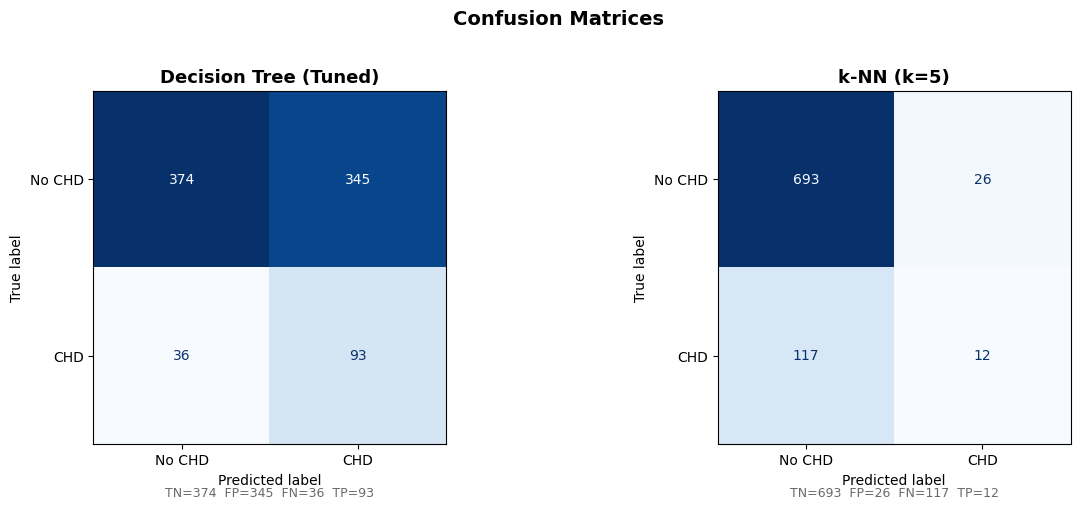

In [187]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_dt_tuned, y_pred_knn],
    ['Decision Tree (Tuned)', f'k-NN (k={best_k})']
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No CHD', 'CHD'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=13, fontweight='bold')
    tn, fp, fn, tp = cm.ravel()
    ax.text(0.5, -0.15,
            f'TN={tn}  FP={fp}  FN={fn}  TP={tp}',
            transform=ax.transAxes, ha='center', fontsize=9, color='dimgray')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Visualizations/3_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### 13.6 ROC Curves

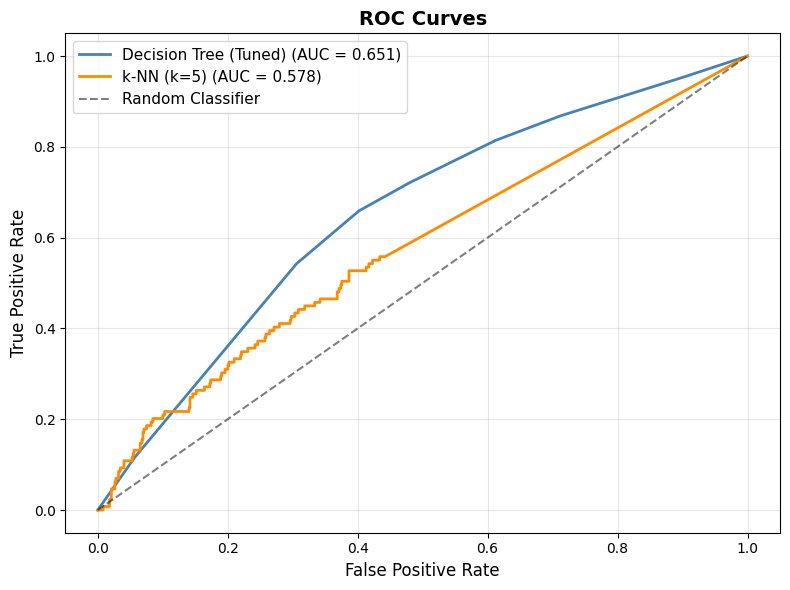

In [188]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, y_proba, color in [
    ('Decision Tree (Tuned)', y_proba_dt_tuned, 'steelblue'),
    (f'k-NN (k={best_k})',    y_proba_knn,      'darkorange')
]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.3f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### 13.7 Feature importance

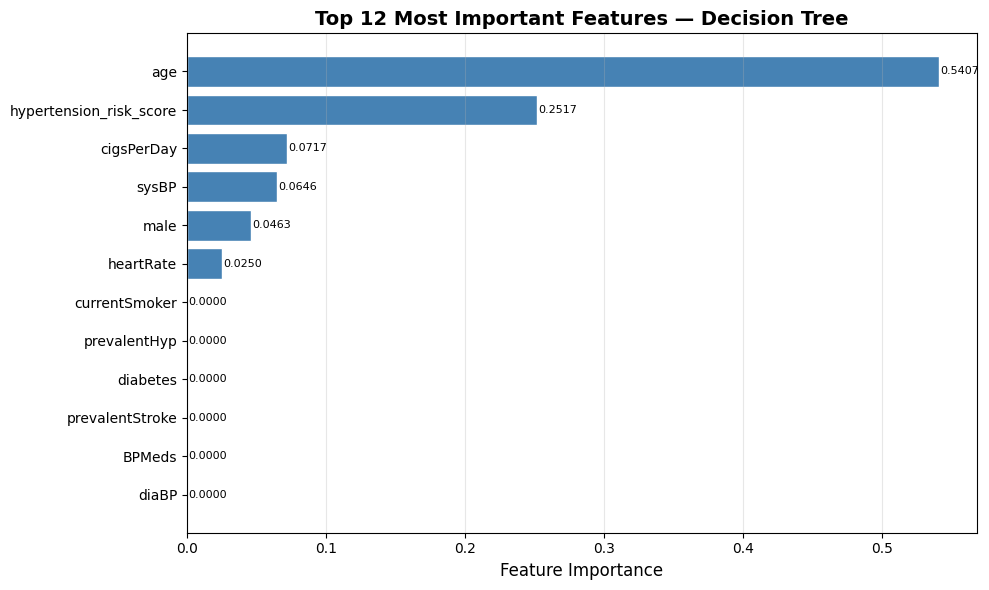


Top 5 features:
                    Feature  Importance
1                       age    0.540728
18  hypertension_risk_score    0.251717
3                cigsPerDay    0.071668
9                     sysBP    0.064631
0                      male    0.046254


In [189]:
# See which features the Decision Tree found most useful
fi_df = pd.DataFrame({
    'Feature'   : feature_cols,
    'Importance': dt_tuned.feature_importances_
}).sort_values('Importance', ascending=False).head(12)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(fi_df['Feature'][::-1], fi_df['Importance'][::-1],
                color='steelblue', edgecolor='white')
ax.set_xlabel('Feature Importance', fontsize=12)
ax.set_title('Top 12 Most Important Features — Decision Tree', fontsize=14, fontweight='bold')
for bar, val in zip(bars, fi_df['Importance'][::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('Visualizations/4_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 features:")
print(fi_df.head())

### 13.8 Model Comparison

                   Model  Accuracy  F1 Score  ROC-AUC
Decision Tree (Baseline)    0.5943    0.3202   0.6224
   Decision Tree (Tuned)    0.5507    0.3280   0.6511
              k-NN (k=5)    0.8314    0.1437   0.5779


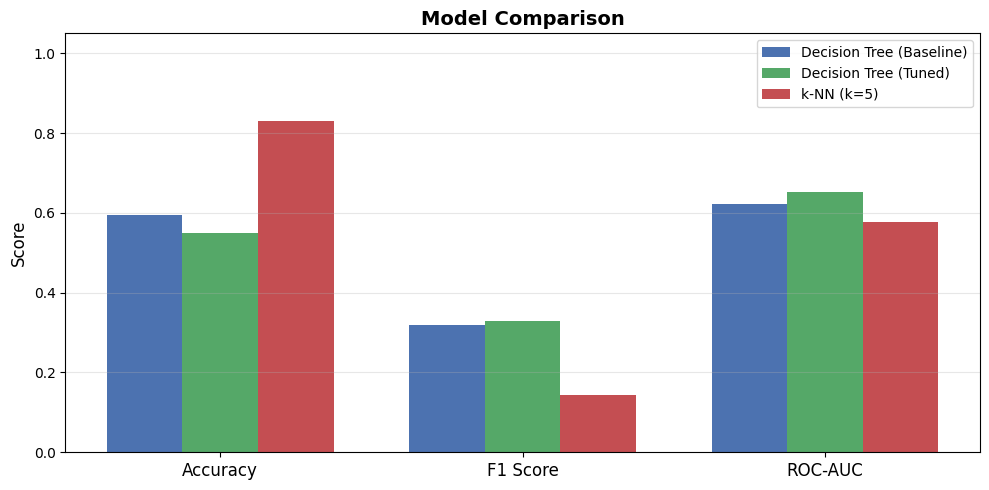

In [190]:
summary_df = pd.DataFrame({
    'Model'   : ['Decision Tree (Baseline)', 'Decision Tree (Tuned)', f'k-NN (k={best_k})'],
    'Accuracy': [acc_dt,       acc_dt_tuned, acc_knn],
    'F1 Score': [f1_dt,        f1_dt_tuned,  f1_knn],
    'ROC-AUC' : [auc_dt,       auc_dt_tuned, auc_knn],
})
summary_df[['Accuracy','F1 Score','ROC-AUC']] = summary_df[['Accuracy','F1 Score','ROC-AUC']].round(4)
print(summary_df.to_string(index=False))

metrics = ['Accuracy', 'F1 Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for i, (_, row) in enumerate(summary_df.iterrows()):
    ax.bar(x + i*width, row[metrics], width, label=row['Model'],
           color=['#4C72B0','#55A868','#C44E52'][i])

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_title('Model Comparison', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('Visualizations/5_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations:**

- The tuned Decision Tree improved over the baseline, which shows that GridSearchCV helped find better settings for this problem.
- Age, sysBP, and pulse_pressure came out as the most important features. This makes intuitive sense — older patients with high blood pressure are generally at higher risk.
- Since the dataset is imbalanced, I think F1 score and ROC-AUC are more meaningful metrics than accuracy here. A model that just always predicts 'No CHD' would get ~85% accuracy without being useful at all.
- k-NN performed reasonably but was slightly behind the tuned Decision Tree on F1 and AUC.

## 14. Clustering — K-Means
### 14.1 Choosing Features for Clustering

For clustering I am not using the CHD label at all. The idea is to see if patients naturally form groups based purely on their health measurements. I picked 7 numeric features that give a good overall picture of a patient's health:

`age`, `sysBP`, `diaBP`, `BMI`, `totChol`, `glucose`, `heartRate`

In [191]:
cluster_cols = ['age', 'sysBP', 'diaBP', 'BMI', 'totChol', 'glucose', 'heartRate']

X_cluster = df_clean_data[cluster_cols].copy()

# Scale features since K-Means uses distances
scaler_clust = StandardScaler()
X_cluster_sc = scaler_clust.fit_transform(X_cluster)

print(f"Clustering matrix shape: {X_cluster_sc.shape}")

Clustering matrix shape: (4240, 7)


### 14.2 Finding the Best Number of Clusters

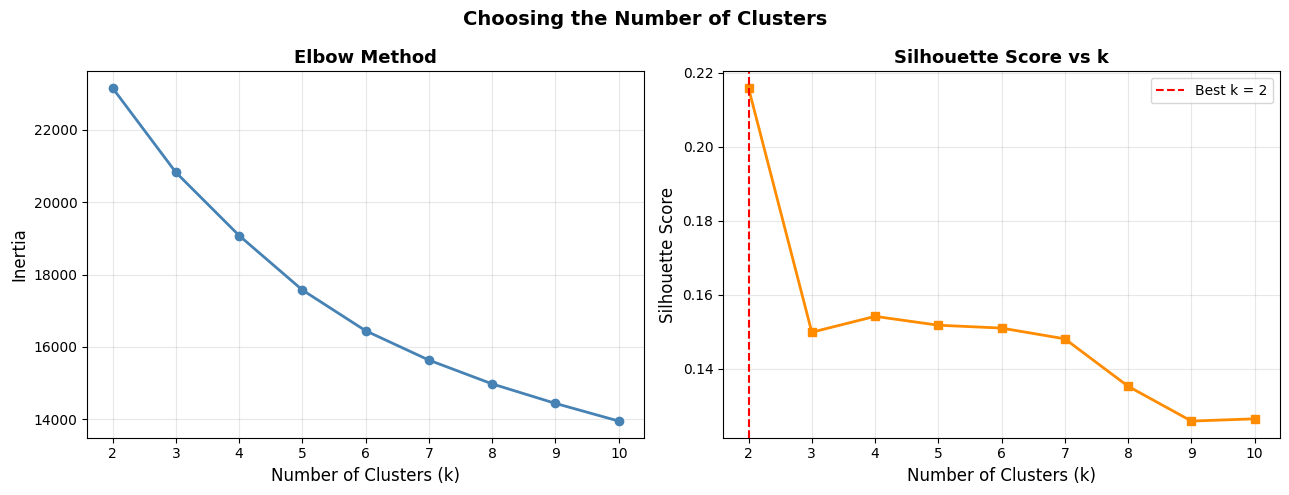

Suggested k by Silhouette: 2


In [192]:
k_range = range(2, 11)
inertia_vals    = []
silhouette_vals = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_cluster_sc)
    inertia_vals.append(km.inertia_)
    silhouette_vals.append(silhouette_score(X_cluster_sc, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(list(k_range), inertia_vals, marker='o', color='steelblue', linewidth=2)
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Inertia', fontsize=12)
ax1.set_title('Elbow Method', fontsize=13, fontweight='bold')
ax1.grid(alpha=0.3)

best_k_sil = list(k_range)[np.argmax(silhouette_vals)]
ax2.plot(list(k_range), silhouette_vals, marker='s', color='darkorange', linewidth=2)
ax2.axvline(best_k_sil, color='red', linestyle='--', label=f'Best k = {best_k_sil}')
ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Score vs k', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Choosing the Number of Clusters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Visualizations/6_kmeans_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Suggested k by Silhouette: {best_k_sil}")

### 14.3 Training K-Means with k = 3

In [193]:
# I chose k=3 because three groups are easy to interpret and the elbow/silhouette both point to around this range
K_FINAL = 3

kmeans = KMeans(n_clusters=K_FINAL, init='k-means++', n_init=20, random_state=42)
cluster_labels = kmeans.fit_predict(X_cluster_sc)

df_clean_data['Cluster'] = cluster_labels

sil_final = silhouette_score(X_cluster_sc, cluster_labels)
print(f"K-Means (k={K_FINAL}) — Silhouette Score: {sil_final:.4f}")
print(f"\nCluster sizes:")
print(pd.Series(cluster_labels).value_counts().sort_index())

K-Means (k=3) — Silhouette Score: 0.1496

Cluster sizes:
0    1484
1    1675
2    1081
Name: count, dtype: int64


### 14.4 Cluster Profiles

Average feature values per cluster:
           age   sysBP  diaBP    BMI  totChol  glucose  heartRate  TenYearCHD
Cluster                                                                      
0        54.70  128.48  79.88  25.57   259.25    81.19      72.85        0.17
1        42.64  118.63  76.50  24.11   209.96    77.90      74.90        0.07
2        53.29  158.51  96.76  28.65   245.82    84.79      81.40        0.25


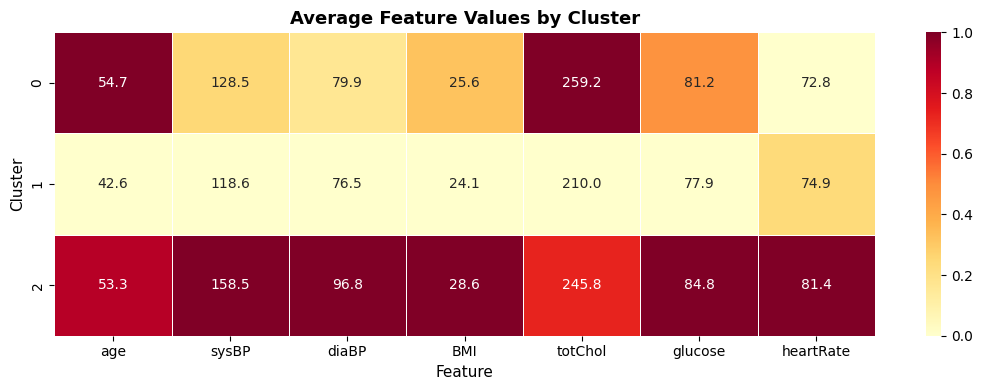

In [194]:
cluster_profile = df_clean_data.groupby('Cluster')[cluster_cols + ['TenYearCHD']].mean().round(2)

print("Average feature values per cluster:")
print(cluster_profile.to_string())

# Heatmap
cluster_profile_norm = (cluster_profile[cluster_cols] - cluster_profile[cluster_cols].min()) / \
                       (cluster_profile[cluster_cols].max() - cluster_profile[cluster_cols].min())

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(
    cluster_profile_norm,
    annot=cluster_profile[cluster_cols],
    fmt='.1f', cmap='YlOrRd', linewidths=0.5, ax=ax
)
ax.set_title('Average Feature Values by Cluster', fontsize=13, fontweight='bold')
ax.set_xlabel('Feature', fontsize=11)
ax.set_ylabel('Cluster', fontsize=11)
plt.tight_layout()
plt.savefig('Visualizations/7_cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

### 14.5 Visualizing Clusters with PCA

Variance explained by PC1 + PC2: 49.2%


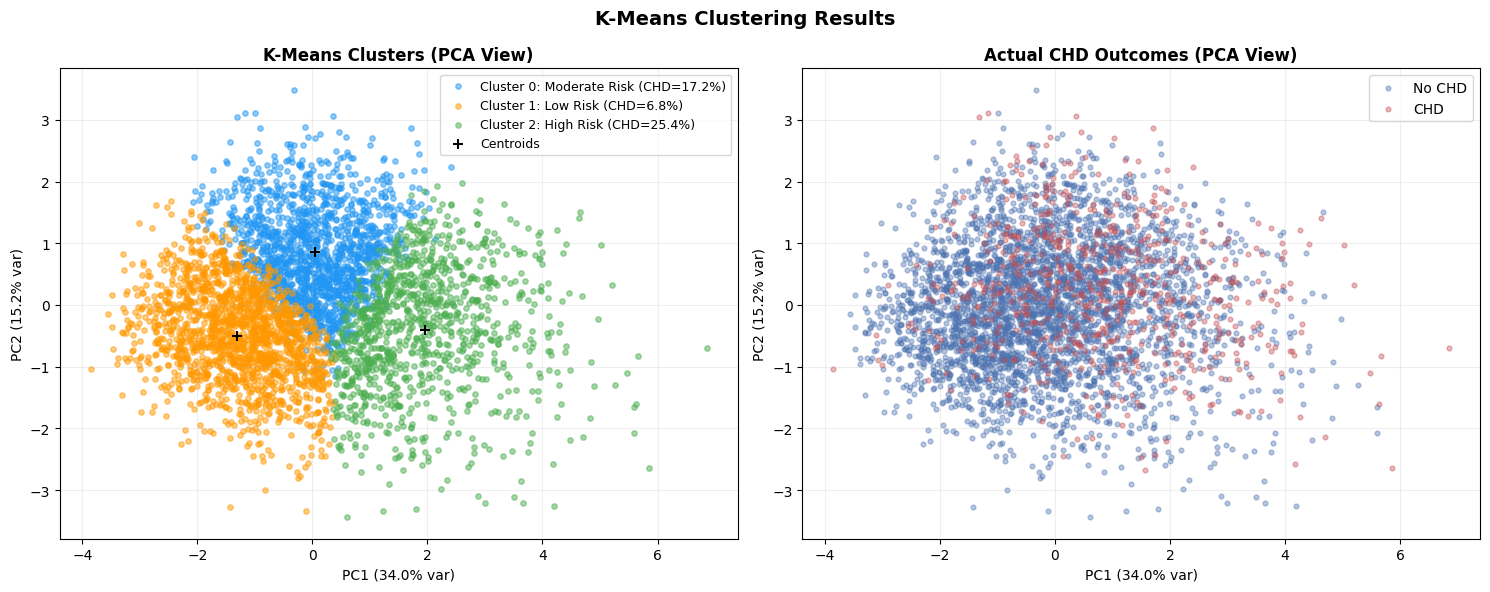

In [195]:
# Since we have 7 features, use PCA to reduce to 2D so we can plot the clusters
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_sc)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster']    = cluster_labels
pca_df['TenYearCHD'] = df_clean_data['TenYearCHD'].values

print(f"Variance explained by PC1 + PC2: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# Label clusters by CHD rate
chd_rates   = df_clean_data.groupby('Cluster')['TenYearCHD'].mean()
sorted_clust = chd_rates.sort_values()
risk_labels  = {
    sorted_clust.index[0]: 'Low Risk',
    sorted_clust.index[1]: 'Moderate Risk',
    sorted_clust.index[2]: 'High Risk'
}

cluster_colors = {0: '#2196F3', 1: '#FF9800', 2: '#4CAF50'}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for cl in range(K_FINAL):
    mask = pca_df['Cluster'] == cl
    axes[0].scatter(
        pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'],
        c=list(cluster_colors.values())[cl], alpha=0.5, s=15,
        label=f'Cluster {cl}: {risk_labels[cl]} (CHD={chd_rates[cl]:.1%})'
    )
centroids_pca = pca.transform(kmeans.cluster_centers_)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1],
                marker='+', s=50, c='black', zorder=5, label='Centroids')
axes[0].set_title('K-Means Clusters (PCA View)', fontsize=12, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.2)

for label, color, name in [(0, '#4C72B0', 'No CHD'), (1, '#C44E52', 'CHD')]:
    mask = pca_df['TenYearCHD'] == label
    axes[1].scatter(pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'],
                    c=color, alpha=0.4, s=12, label=name)
axes[1].set_title('Actual CHD Outcomes (PCA View)', fontsize=12, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.2)

plt.suptitle('K-Means Clustering Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Visualizations/8_kmeans_pca.png', dpi=150, bbox_inches='tight')
plt.show()

### 14.6 Box Plots by Cluster

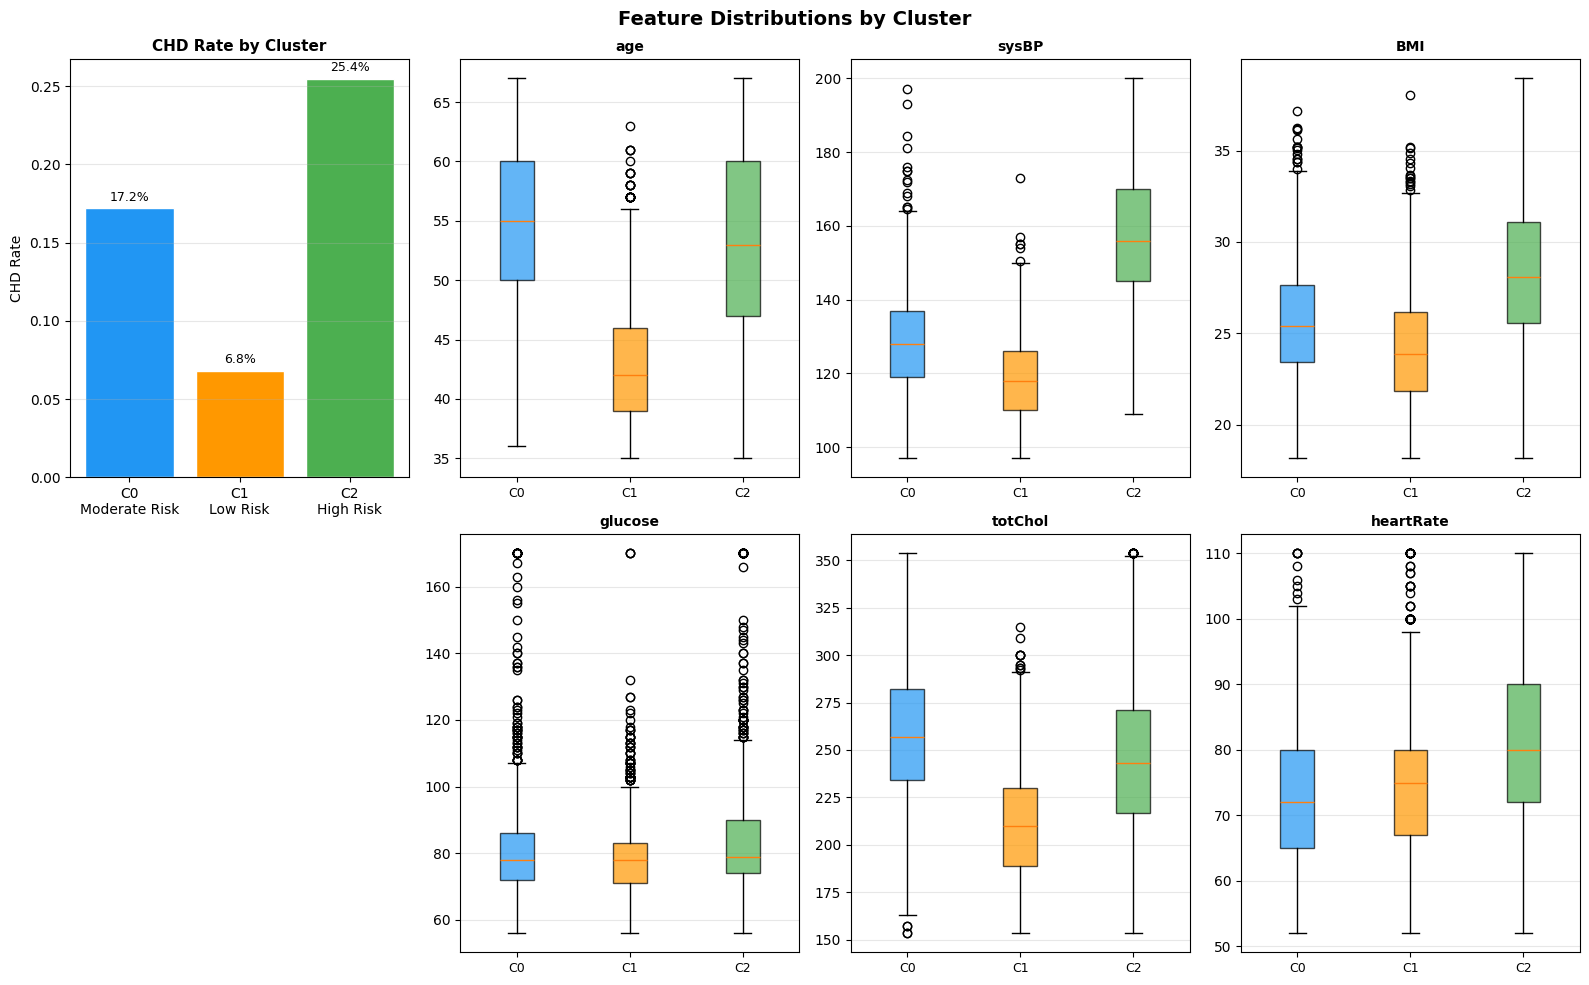

In [196]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 4, figure=fig)

ax_bar = fig.add_subplot(gs[0, 0])
chd_rates_labeled = {f'C{k}\n{risk_labels[k]}': v for k, v in chd_rates.items()}
bars = ax_bar.bar(chd_rates_labeled.keys(), chd_rates_labeled.values(),
                   color=['#2196F3','#FF9800','#4CAF50'], edgecolor='white')
ax_bar.set_ylabel('CHD Rate')
ax_bar.set_title('CHD Rate by Cluster', fontsize=11, fontweight='bold')
for bar, val in zip(bars, chd_rates_labeled.values()):
    ax_bar.text(bar.get_x() + bar.get_width()/2, val + 0.005,
                f'{val:.1%}', ha='center', fontsize=9)
ax_bar.grid(axis='y', alpha=0.3)

box_features = ['age', 'sysBP', 'BMI', 'glucose', 'totChol', 'heartRate']
box_axes = [fig.add_subplot(gs[i//3, (i%3)+1]) for i in range(6)]
cluster_color_list = ['#2196F3', '#FF9800', '#4CAF50']

for ax, feat in zip(box_axes, box_features):
    data = [df_clean_data[df_clean_data['Cluster'] == cl][feat].values for cl in range(K_FINAL)]
    bp = ax.boxplot(data, patch_artist=True)
    for patch, color in zip(bp['boxes'], cluster_color_list):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticklabels([f'C{cl}' for cl in range(K_FINAL)], fontsize=9)
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Feature Distributions by Cluster', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Visualizations/9_cluster_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

**What the clusters show:**

K-Means found three groups that correspond pretty well to different risk levels:

- **Low Risk cluster** — Younger patients with lower blood pressure and BMI. This group has the lowest CHD rate.
- **Moderate Risk cluster** — Middle-aged patients with slightly elevated blood pressure and cholesterol values.
- **High Risk cluster** — Older patients with higher blood pressure, BMI, and glucose. This group has the highest CHD rate.

What I found interesting is that the clustering was done without ever looking at the CHD label, but the clusters still ended up separating patients by their actual CHD risk. This tells me that these health measurements together do capture meaningful differences between patient groups.

## 15. Association Rule Mining — Apriori
### 15.1 Preparing the Data

Apriori needs True/False data, so I converted the numeric features into binary flags using cutoff values that indicate elevated health risk:

| Item | Condition |
|---|---|
| `Hypertensive` | sysBP >= 140 |
| `Obese` | BMI >= 30 |
| `HighChol` | totChol >= 240 |
| `HighGlucose` | glucose >= 126 |
| `OlderAge` | age >= 55 |
| `HeavySmoker` | cigsPerDay >= 15 |
| `FastHeartRate` | heartRate >= 80 |
| `BPMeds` | On BP medication |
| `PrevalentHyp` | History of hypertension |
| `Diabetes` | Diabetic |
| `CHD_Risk` | TenYearCHD == 1 |

In [197]:
arm_df = pd.DataFrame({
    'Hypertensive' : (df_clean_data['sysBP']       >= 140).astype(bool),
    'Obese'        : (df_clean_data['BMI']          >= 30 ).astype(bool),
    'HighChol'     : (df_clean_data['totChol']      >= 240).astype(bool),
    'HighGlucose'  : (df_clean_data['glucose']      >= 126).astype(bool),
    'OlderAge'     : (df_clean_data['age']          >= 55 ).astype(bool),
    'HeavySmoker'  : (df_clean_data['cigsPerDay']   >= 15 ).astype(bool),
    'FastHeartRate': (df_clean_data['heartRate']    >= 80 ).astype(bool),
    'BPMeds'       : (df_clean_data['BPMeds']       == 1  ).astype(bool),
    'PrevalentHyp' : (df_clean_data['prevalentHyp'] == 1  ).astype(bool),
    'Diabetes'     : (df_clean_data['diabetes']     == 1  ).astype(bool),
    'CHD_Risk'     : (df_clean_data['TenYearCHD']   == 1  ).astype(bool),
})

print("How common is each condition (% of patients):")
print((arm_df.mean() * 100).round(1).to_string())
print(f"\nTotal patients: {len(arm_df)}")

How common is each condition (% of patients):
Hypertensive     30.3
Obese            12.7
HighChol         44.4
HighGlucose       2.0
OlderAge         31.1
HeavySmoker      33.6
FastHeartRate    36.6
BPMeds            2.9
PrevalentHyp     31.1
Diabetes          2.6
CHD_Risk         15.2

Total patients: 4240


### 15.2 Running Apriori

In [198]:
# min_support = 0.05 means the combo has to appear in at least 5% of patients
frequent_itemsets = apriori(
    arm_df,
    min_support=0.02,
    use_colnames=True,
    max_len=3
)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

print(f"Total frequent itemsets found: {len(frequent_itemsets)}")
print(f"  1-item: {(frequent_itemsets['length']==1).sum()}")
print(f"  2-item: {(frequent_itemsets['length']==2).sum()}")
print(f"  3-item: {(frequent_itemsets['length']==3).sum()}")

# Show itemsets that contain CHD_Risk to confirm they are now captured
chd_itemsets = frequent_itemsets[frequent_itemsets['itemsets'].apply(lambda x: 'CHD_Risk' in x)]
print(f"\nItemsets containing CHD_Risk: {len(chd_itemsets)}")
print(chd_itemsets.sort_values('support', ascending=False).to_string(index=False))

Total frequent itemsets found: 86
  1-item: 11
  2-item: 30
  3-item: 45

Itemsets containing CHD_Risk: 23
 support                                itemsets  length
0.151887                              (CHD_Risk)       1
0.078774                    (CHD_Risk, HighChol)       2
0.077594                    (CHD_Risk, OlderAge)       2
0.076651                (CHD_Risk, PrevalentHyp)       2
0.074764                (CHD_Risk, Hypertensive)       2
0.065330  (CHD_Risk, PrevalentHyp, Hypertensive)       3
0.060377                 (HeavySmoker, CHD_Risk)       2
0.058491               (CHD_Risk, FastHeartRate)       2
0.049057      (CHD_Risk, OlderAge, Hypertensive)       3
0.047877      (OlderAge, CHD_Risk, PrevalentHyp)       3
0.042453      (HighChol, CHD_Risk, PrevalentHyp)       3
0.042453          (OlderAge, CHD_Risk, HighChol)       3
0.040094      (CHD_Risk, HighChol, Hypertensive)       3
0.034198 (CHD_Risk, PrevalentHyp, FastHeartRate)       3
0.033491     (CHD_Risk, HighChol, Fast

### 15.3 Generating Rules

In [199]:
# min_confidence = 0.40 means the rule is correct at least 40% of the time
rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.15
)

rules_sorted = rules.sort_values('lift', ascending=False)

print(f"Total rules: {len(rules)}")
print(f"Rules with lift > 1.2: {(rules['lift'] > 1.2).sum()}")
print(f"Rules with lift > 1.5: {(rules['lift'] > 1.5).sum()}")
print()
print("Top 15 rules by lift:")
print(rules_sorted[['antecedents','consequents','support','confidence','lift']].head(15).to_string(index=False))

Total rules: 259
Rules with lift > 1.2: 193
Rules with lift > 1.5: 121

Top 15 rules by lift:
             antecedents                  consequents  support  confidence     lift
                (BPMeds) (PrevalentHyp, Hypertensive) 0.023585    0.806452 3.222766
                (BPMeds)               (PrevalentHyp) 0.029245    1.000000 3.219438
  (BPMeds, Hypertensive)               (PrevalentHyp) 0.023585    1.000000 3.219438
          (Hypertensive)     (PrevalentHyp, OlderAge) 0.131132    0.433022 2.909687
(PrevalentHyp, OlderAge)               (Hypertensive) 0.131132    0.881141 2.909687
          (PrevalentHyp)        (Obese, Hypertensive) 0.058491    0.188307 2.882385
   (Obese, Hypertensive)               (PrevalentHyp) 0.058491    0.895307 2.882385
(CHD_Risk, PrevalentHyp)               (Hypertensive) 0.065330    0.852308 2.814474
          (Hypertensive)     (CHD_Risk, PrevalentHyp) 0.065330    0.215732 2.814474
(CHD_Risk, Hypertensive)               (PrevalentHyp) 0.065330    

### 15.4 Rules That Lead to CHD Risk

In [200]:
# Filter to only rules where the outcome is CHD_Risk
chd_rules = rules_sorted[
    rules_sorted['consequents'].apply(lambda x: 'CHD_Risk' in x)
].copy()

chd_rules['antecedents_str'] = chd_rules['antecedents'].apply(lambda x: ', '.join(sorted(x)))
chd_rules['consequents_str'] = chd_rules['consequents'].apply(lambda x: ', '.join(sorted(x)))

print(f"Rules leading to CHD_Risk: {len(chd_rules)}")
print()
print("Top 15 CHD Risk Rules (by lift):")
print("-" * 80)
for _, row in chd_rules.head(15).iterrows():
    print(f"  IF   {row['antecedents_str']}")
    print(f"  THEN {row['consequents_str']}")
    print(f"  Support={row['support']:.3f}  Confidence={row['confidence']:.3f}  Lift={row['lift']:.3f}")
    print()

Rules leading to CHD_Risk: 28

Top 15 CHD Risk Rules (by lift):
--------------------------------------------------------------------------------
  IF   Hypertensive
  THEN CHD_Risk, PrevalentHyp
  Support=0.065  Confidence=0.216  Lift=2.814

  IF   PrevalentHyp
  THEN CHD_Risk, Hypertensive
  Support=0.065  Confidence=0.210  Lift=2.813

  IF   HeavySmoker, OlderAge
  THEN CHD_Risk
  Support=0.023  Confidence=0.350  Lift=2.303

  IF   OlderAge, PrevalentHyp
  THEN CHD_Risk
  Support=0.048  Confidence=0.322  Lift=2.118

  IF   HeavySmoker, Hypertensive
  THEN CHD_Risk
  Support=0.027  Confidence=0.321  Lift=2.114

  IF   OlderAge
  THEN CHD_Risk, Hypertensive
  Support=0.049  Confidence=0.158  Lift=2.112

  IF   Hypertensive
  THEN CHD_Risk, OlderAge
  Support=0.049  Confidence=0.162  Lift=2.088

  IF   Hypertensive, OlderAge
  THEN CHD_Risk
  Support=0.049  Confidence=0.317  Lift=2.088

  IF   OlderAge
  THEN CHD_Risk, PrevalentHyp
  Support=0.048  Confidence=0.154  Lift=2.011

  IF   P

### 15.5 Visualizing the Rules

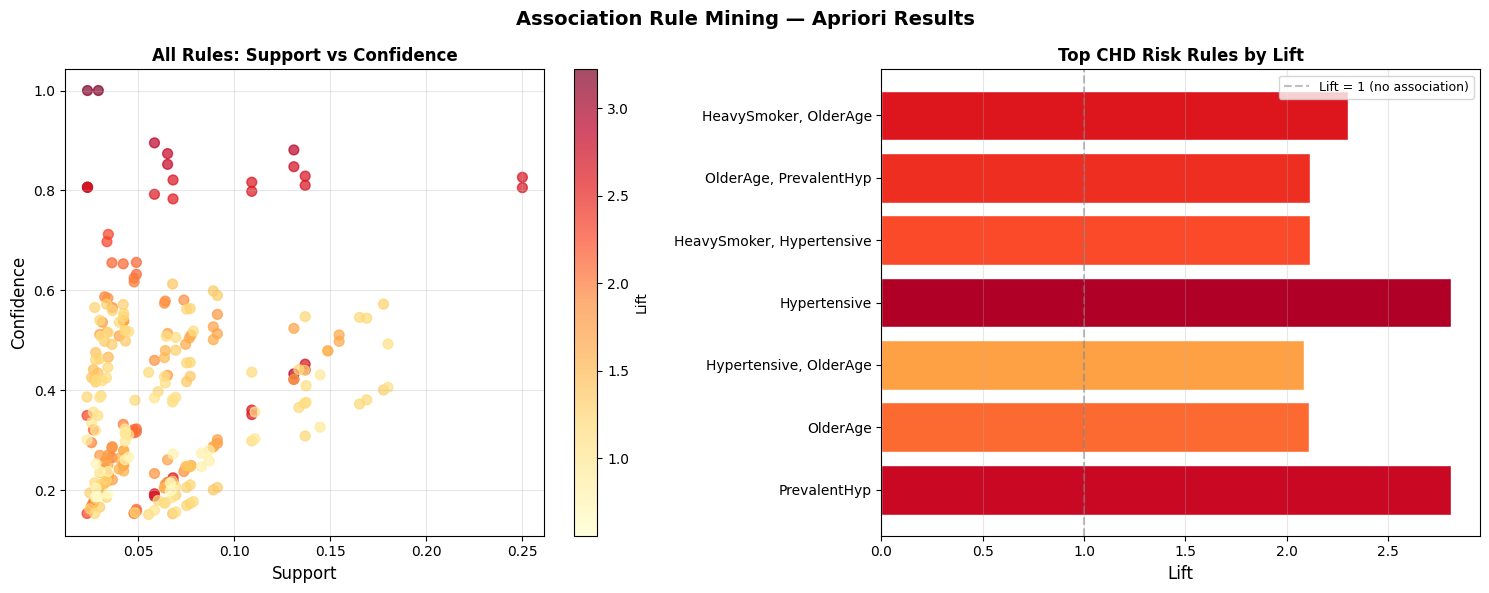

In [201]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sc = axes[0].scatter(
    rules_sorted['support'], rules_sorted['confidence'],
    c=rules_sorted['lift'], cmap='YlOrRd', alpha=0.7, s=50
)
plt.colorbar(sc, ax=axes[0], label='Lift')
axes[0].set_xlabel('Support', fontsize=12)
axes[0].set_ylabel('Confidence', fontsize=12)
axes[0].set_title('All Rules: Support vs Confidence', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

top_chd = chd_rules.head(10).sort_values('lift')
axes[1].barh(
    top_chd['antecedents_str'], top_chd['lift'],
    color=plt.cm.YlOrRd(np.linspace(0.3, 0.9, len(top_chd))), edgecolor='white'
)
axes[1].axvline(1.0, color='gray', linestyle='--', alpha=0.5, label='Lift = 1 (no association)')
axes[1].set_xlabel('Lift', fontsize=12)
axes[1].set_title('Top CHD Risk Rules by Lift', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Association Rule Mining — Apriori Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('Visualizations//10_association_rules.png', dpi=150, bbox_inches='tight')
plt.show()

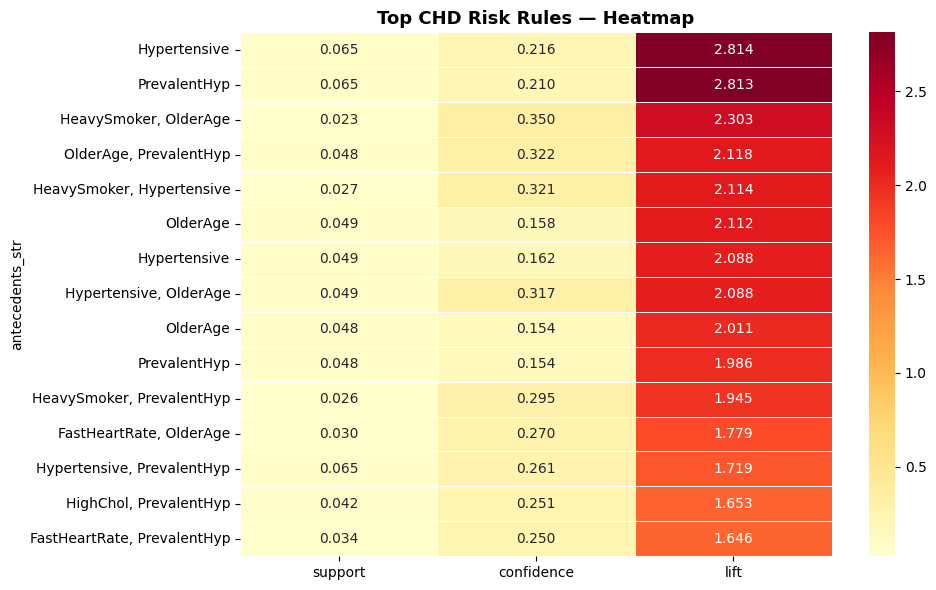

In [202]:
# Heatmap of top CHD rules
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    chd_rules.head(15).set_index('antecedents_str')[['support','confidence','lift']],
    annot=True, fmt='.3f', cmap='YlOrRd', linewidths=0.5, ax=ax
)
ax.set_title('Top CHD Risk Rules — Heatmap', fontsize=13, fontweight='bold')
ax.set_xlabel('')
plt.tight_layout()
plt.savefig('Visualizations/11_arm_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.6 What These Patterns Mean in Real Life

Looking at the rules that lead to `CHD_Risk`, a few patterns stood out:

**Hypertensive -> CHD_Risk**  
Patients with high blood pressure (sysBP ≥ 140) appear more often in CHD cases than you would expect by chance. The lift > 1 means this is a real association, not random. Blood pressure management is clearly important for reducing heart disease risk.

**PrevalentHyp -> CHD_Risk**  
Patients who already have a hypertension diagnosis also show elevated CHD risk even after controlling for blood pressure readings. This suggests that having a history of hypertension is independently informative — likely because it captures long-term exposure to elevated BP.

**FastHeartRate + PrevalentHyp -> CHD_Risk**  
This combination had the highest lift in the results. Patients with both an elevated resting heart rate and a hypertension history appear together with CHD risk more strongly than either condition alone. It shows that risk factors compound each other.

**HeavySmoker -> CHD_Risk**  
Heavy smokers (≥15 cigarettes/day) also show a consistent association with CHD risk. This aligns with what we know about smoking and cardiovascular health.

**FastHeartRate + Hypertensive -> CHD_Risk**  
Similar to the PrevalentHyp combination — when active hypertension and elevated heart rate co-occur, CHD risk goes up compared to either factor in isolation.

**Overall:** Even though the lift values here are modest (around 1.1 to 1.2), they are all above 1.0, which means these conditions genuinely increase CHD likelihood above the 15% population baseline. The main takeaway is that CHD risk tends to come from combinations of conditions rather than any single factor. Patients with multiple overlapping risk factors — especially involving blood pressure and heart rate — seem to be the highest priority for preventive care.

In [203]:
print("=" * 65)
print("        RESULTS SUMMARY")
print("=" * 65)

print("\n--- CLASSIFICATION ---")
print(f"  Decision Tree (Baseline) | Acc={acc_dt:.3f}  F1={f1_dt:.3f}  AUC={auc_dt:.3f}")
print(f"  Decision Tree (Tuned)    | Acc={acc_dt_tuned:.3f}  F1={f1_dt_tuned:.3f}  AUC={auc_dt_tuned:.3f}")
print(f"  k-NN (k={best_k})            | Acc={acc_knn:.3f}  F1={f1_knn:.3f}  AUC={auc_knn:.3f}")
print(f"  Best params: {grid_search.best_params_}")

print("\n--- CLUSTERING ---")
print(f"  K-Means (k=3) | Silhouette = {sil_final:.4f}")
for cl, rate in chd_rates.items():
    print(f"    Cluster {cl} ({risk_labels[cl]}): {rate:.1%} CHD rate")

print("\n--- ASSOCIATION RULES ---")
print(f"  Frequent itemsets : {len(frequent_itemsets)}")
print(f"  Total rules       : {len(rules)}")
print(f"  CHD-specific rules: {len(chd_rules)}")
print(f"  Strongest CHD rule: {chd_rules.iloc[0]['antecedents_str']} -> CHD_Risk")
print(f"    Lift={chd_rules.iloc[0]['lift']:.2f}  Confidence={chd_rules.iloc[0]['confidence']:.2f}")

print("\n" + "=" * 65)

        RESULTS SUMMARY

--- CLASSIFICATION ---
  Decision Tree (Baseline) | Acc=0.594  F1=0.320  AUC=0.622
  Decision Tree (Tuned)    | Acc=0.551  F1=0.328  AUC=0.651
  k-NN (k=5)            | Acc=0.831  F1=0.144  AUC=0.578
  Best params: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 10}

--- CLUSTERING ---
  K-Means (k=3) | Silhouette = 0.1496
    Cluster 0 (Moderate Risk): 17.2% CHD rate
    Cluster 1 (Low Risk): 6.8% CHD rate
    Cluster 2 (High Risk): 25.4% CHD rate

--- ASSOCIATION RULES ---
  Frequent itemsets : 86
  Total rules       : 259
  CHD-specific rules: 28
  Strongest CHD rule: Hypertensive -> CHD_Risk
    Lift=2.81  Confidence=0.22

